## Time Series Modelling and Forecasting of Daily Oil Prices Using ARIMA and Machine Learning Approaches

- This study investigates the modelling and forecasting of daily oil price time series data using established statistical and machine learning techniques. The analysis begins with exploratory data analysis and formal stationarity testing to understand the underlying characteristics of the series. An ARIMA model is then developed, with optimal parameters selected through a comprehensive grid search using the AIC criterion. Model performance is evaluated using out-of-sample testing, residual diagnostics, and forecast accuracy metrics. Finally, the model is used to generate a 24-month forecast with confidence intervals, providing insights into future oil price behaviour and the reliability of the modelling approach.

In [50]:
# Step 1 — Imports + Global Plot Style + Helpers
"""
Purpose:
Import all libraries required for data handling, visualisation, stationarity testing,
diagnostics, ARIMA modelling, and evaluation.

Also define a clean plotting style and helper utilities so the notebook remains
portable and readable.
"""

import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# Global visual style
# -----------------------------
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25
})

# -----------------------------
# Colour palette
# -----------------------------
COL = {
    "red": "#d62828",
    "orange": "#f77f00",
    "pink": "#e76f51",
    "yellow": "#e9c46a",
    "green": "#2a9d8f",
    "purple": "#9d4edd",
    "teal": "#0081a7",
    "grey": "#6c757d",
    "black": "#111111",
    "rose": "#c9184a",
    "olive": "#7f8c00"
}

# -----------------------------
# Helper functions
# -----------------------------
def prettify_time_axis(ax):
    """Format date ticks neatly and keep the axis readable."""
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))


def save_and_show(fig, filename, fig_dir):
    """
    Save a figure at high resolution and display it below the cell.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save and show.
    filename : str
        Output filename. '.png' is added automatically if missing.
    fig_dir : pathlib.Path
        Directory where figures are stored.
    """
    fig_dir = Path(fig_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)

    if not filename.lower().endswith(".png"):
        filename += ".png"

    fig.tight_layout()
    fig.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def compute_metrics(y_true, y_pred):
    """
    Compute standard regression metrics for forecasting evaluation.
    """
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return rmse, mae


# Practical default for ARIMA fitting
ARIMA_FIT_KWARGS = {"maxiter": 50}

print("Imports and helpers loaded successfully.")

Imports and helpers loaded successfully.


In [51]:
# Step 2 — Project Paths + Data File + Figures Folder
"""
Purpose:
Define project, data, and figure paths in a portable way so the notebook runs on:
- local VS Code / Jupyter
- Google Colab
- a marker's machine

without requiring manual path edits in most common cases.
"""

from pathlib import Path

# Optional preferred absolute project location on your own machine
ABS_PROJECT_ROOT = Path(r"C:\Users\girid\OneDrive\Desktop\Data Science Advanced Research")

cwd = Path.cwd()

# Common likely locations for the dataset
data_candidates = [
    cwd / "oil_prices_2426.csv",
    cwd / "Data" / "oil_prices_2426.csv",
    cwd.parent / "oil_prices_2426.csv",
    cwd.parent / "Data" / "oil_prices_2426.csv",
    cwd.parent.parent / "oil_prices_2426.csv",
    cwd.parent.parent / "Data" / "oil_prices_2426.csv",
    ABS_PROJECT_ROOT / "Data" / "oil_prices_2426.csv",
    Path("/content/oil_prices_2426.csv"),
    Path("/content/sample_data/oil_prices_2426.csv"),
    Path("/mnt/data/oil_prices_2426.csv")
]

DATA_PATH = None
for candidate in data_candidates:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break

if DATA_PATH is None:
    checked_paths = "\n".join(str(p) for p in data_candidates)
    raise FileNotFoundError(
        "Could not locate 'oil_prices_2426.csv'.\n\n"
        f"Current working directory: {cwd}\n\n"
        "Checked these locations:\n"
        f"{checked_paths}\n\n"
        "Place the file either beside the notebook, inside a Data/ folder, "
        "or update the data_candidates list."
    )

# Infer a sensible project root
if DATA_PATH.parent.name.lower() == "data":
    PROJECT_ROOT = DATA_PATH.parent.parent
else:
    PROJECT_ROOT = DATA_PATH.parent

# Choose a writable figures directory
figure_candidates = [
    PROJECT_ROOT / "figures",
    cwd / "figures",
    DATA_PATH.parent / "figures"
]

FIG_DIR = None
for candidate in figure_candidates:
    try:
        candidate.mkdir(parents=True, exist_ok=True)
        test_file = candidate / ".write_test"
        test_file.write_text("ok", encoding="utf-8")
        test_file.unlink()
        FIG_DIR = candidate.resolve()
        break
    except Exception:
        continue

if FIG_DIR is None:
    raise PermissionError("Could not create a writable figures directory.")

print(f"Project root detected: {PROJECT_ROOT}")
print(f"Data path:             {DATA_PATH}")
print(f"Figures folder:        {FIG_DIR}")

Project root detected: C:\Users\girid\OneDrive\Desktop\Data Science Advanced Research
Data path:             C:\Users\girid\OneDrive\Desktop\Data Science Advanced Research\Data\oil_prices_2426.csv
Figures folder:        C:\Users\girid\OneDrive\Desktop\Data Science Advanced Research\figures


In [52]:
# Step 3 — Load Data + Strict Integrity Checks
"""
Purpose:
Load the dataset, parse dates safely, validate the time index, and handle missing dates transparently.
These checks reduce silent errors and strengthen the reliability of all later time series modelling steps.
"""

df = pd.read_csv(DATA_PATH)

# -----------------------------
# Standardise column names
# -----------------------------
df.columns = [
    c.strip().lower().replace(" (dollars)", "").replace(" ", "_")
    for c in df.columns
]

# -----------------------------
# Validate required columns
# -----------------------------
required_cols = {"date", "price"}
missing_cols = required_cols.difference(df.columns)

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}. "
        f"Found columns: {list(df.columns)}"
    )

# -----------------------------
# Inspect raw date values
# -----------------------------
print("Sample raw date values:", df["date"].astype(str).head(5).tolist())

# -----------------------------
# Date parsing
# -----------------------------
DATE_FORMAT = None  # set explicitly if known, e.g. "%Y-%m-%d"

if DATE_FORMAT is not None:
    df["date"] = pd.to_datetime(df["date"], format=DATE_FORMAT, errors="raise")
else:
    df["date"] = pd.to_datetime(df["date"], errors="raise")

# -----------------------------
# Sort and remove duplicate dates
# -----------------------------
duplicate_dates = int(df.duplicated(subset=["date"]).sum())
df = df.sort_values("date").drop_duplicates(subset=["date"], keep="last")

# -----------------------------
# Set index and enforce numeric prices
# -----------------------------
df = df.set_index("date")
df["price"] = pd.to_numeric(df["price"], errors="raise")

# -----------------------------
# Strict index checks
# -----------------------------
if not df.index.is_monotonic_increasing:
    raise ValueError("Date index is not sorted correctly.")

if df.index.has_duplicates:
    raise ValueError("Duplicate dates remain after cleaning.")

print(f"Duplicate date rows removed: {duplicate_dates}")
print(f"Start date: {df.index.min()}")
print(f"End date:   {df.index.max()}")
print(f"Observations before daily reindexing: {len(df)}")

# -----------------------------
# Build complete daily index
# -----------------------------
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = full_index.difference(df.index)

print(f"Expected daily observations: {len(full_index)}")
print(f"Missing dates detected: {len(missing_dates)}")
print("First 10 missing dates:", list(missing_dates[:10]))

# -----------------------------
# Reindex to daily frequency
# -----------------------------
df = df.reindex(full_index)
df.index.name = "date"

missing_price = int(df["price"].isna().sum())
missing_frac = missing_price / len(df)

print(f"Missing prices after reindexing: {missing_price} ({missing_frac:.2%})")

# -----------------------------
# Gap handling policy
# -----------------------------
# Important:
# We do NOT drop rows after daily reindexing, because dropping would destroy the fixed daily frequency
# required by later time-series operations. Instead, we only interpolate small gaps.
MAX_INTERP_FRAC = 0.01  # interpolate only if <= 1% of the full series is missing

if missing_price > 0:
    if missing_frac <= MAX_INTERP_FRAC:
        df["price"] = df["price"].interpolate(method="time", limit_direction="both")
        print("Gap strategy used: time interpolation (small-gap policy).")
    else:
        raise ValueError(
            f"Missing fraction {missing_frac:.2%} is too large for safe interpolation. "
            "Review the dataset before modelling."
        )
else:
    print("Gap strategy used: no interpolation needed.")

# -----------------------------
# Final integrity checks
# -----------------------------
if df["price"].isna().any():
    raise ValueError("Missing prices remain after interpolation.")

df = df.asfreq("D")

print(f"Final observations: {len(df)}")
print(f"Final missing prices: {int(df['price'].isna().sum())}")
print(f"Final frequency: {df.index.freqstr if df.index.freq is not None else 'No fixed frequency'}")

display(df.head())
print(df.info())

Sample raw date values: ['21/09/2024', '22/09/2024', '23/09/2024', '24/09/2024', '25/09/2024']
Duplicate date rows removed: 0
Start date: 2024-09-21 00:00:00
End date:   2026-02-02 00:00:00
Observations before daily reindexing: 500
Expected daily observations: 500
Missing dates detected: 0
First 10 missing dates: []
Missing prices after reindexing: 0 (0.00%)
Gap strategy used: no interpolation needed.
Final observations: 500
Final missing prices: 0
Final frequency: D


C:\Users\girid\AppData\Local\Temp\ipykernel_37088\1175506058.py:43: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="raise")


,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-09-21 to 2026-02-02
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   500 non-null    float64
dtypes: float64(1)
memory usage: 7.8 KB
None


In [53]:
# Step 4 — Summary Statistics + Outlier Scan
"""
Purpose:
Generate summary statistics and perform a simple outlier scan using the IQR rule.
This helps describe the central tendency, dispersion, and whether extreme values dominate the series.

Note:
For a trending time series, IQR-based outliers should be interpreted cautiously because
high later values may reflect genuine trend rather than abnormal errors.
"""

price_desc = df["price"].describe()
print(price_desc)

q1, q3 = df["price"].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["price"] < lower) | (df["price"] > upper)].copy()

print(f"\nIQR thresholds:")
print(f"Lower bound: {lower:.4f}")
print(f"Upper bound: {upper:.4f}")
print(f"IQR outliers detected: {len(outliers)}")

display(outliers.head(10))

count    500.000000
mean      75.873980
std       42.912398
min       16.480000
25%       35.372500
50%       64.290000
75%      111.572500
max      158.780000
Name: price, dtype: float64

IQR thresholds:
Lower bound: -78.9275
Upper bound: 225.8725
IQR outliers detected: 0


,price
date,


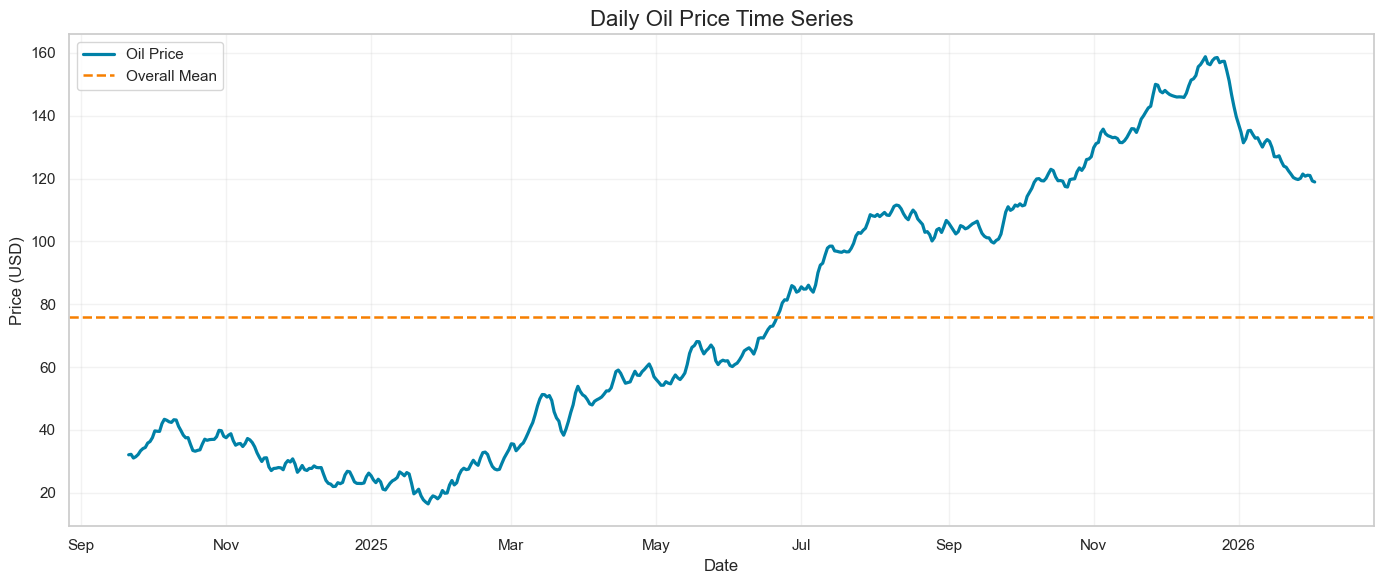

In [54]:
# Plot 1 — Daily Oil Price Time Series
"""
Purpose:
Visualise the full oil price series to identify long-term movement, sharp shifts, and broad trend behaviour.
This is the main introductory plot for the dataset and supports the non-stationarity discussion.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["price"], color=COL["teal"], linewidth=2.3, label="Oil Price")
ax.axhline(
    df["price"].mean(),
    color=COL["orange"],
    linestyle="--",
    linewidth=1.8,
    label="Overall Mean"
)

ax.set_title("Daily Oil Price Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "01_time_series_plot", FIG_DIR)


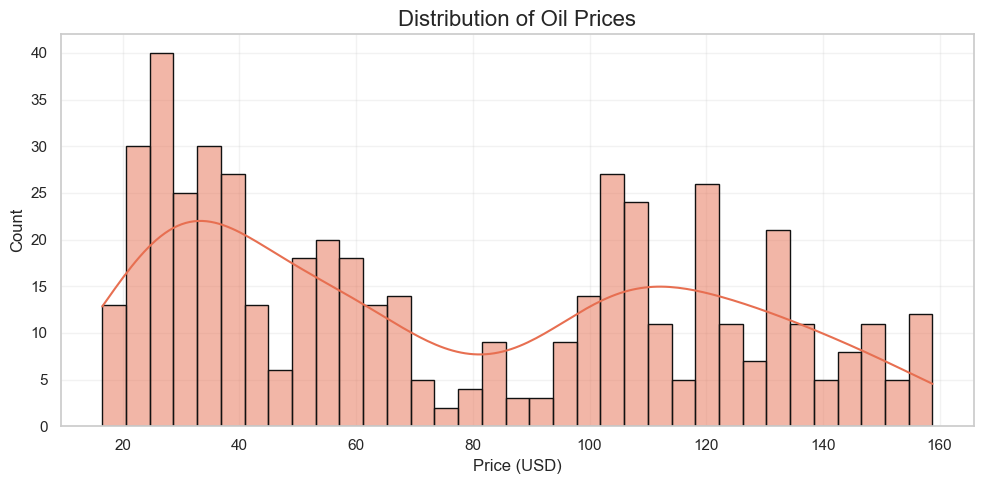

In [55]:
# Plot 2 — Distribution of Oil Prices
"""
Purpose:
Examine the distribution of oil prices using a histogram and density estimate.
This helps identify skewness, spread, and whether the series may benefit from transformation.
"""

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=35,
    kde=True,
    color=COL["pink"],
    edgecolor=COL["black"],
    ax=ax
)

ax.set_title("Distribution of Oil Prices")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Count")

save_and_show(fig, "02_price_distribution", FIG_DIR)


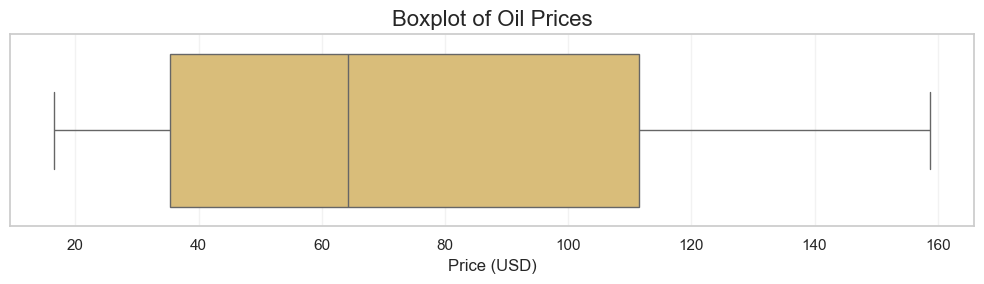

In [56]:

# Plot 3 — Boxplot of Oil Prices
"""
Purpose:
Use a boxplot to summarise the median, interquartile range, and potential extreme values.
This complements the histogram and gives a compact view of spread and outlier behaviour.
"""

fig, ax = plt.subplots(figsize=(10, 3))

sns.boxplot(x=df["price"], color=COL["yellow"], ax=ax)

ax.set_title("Boxplot of Oil Prices")
ax.set_xlabel("Price (USD)")

save_and_show(fig, "03_price_boxplot", FIG_DIR)


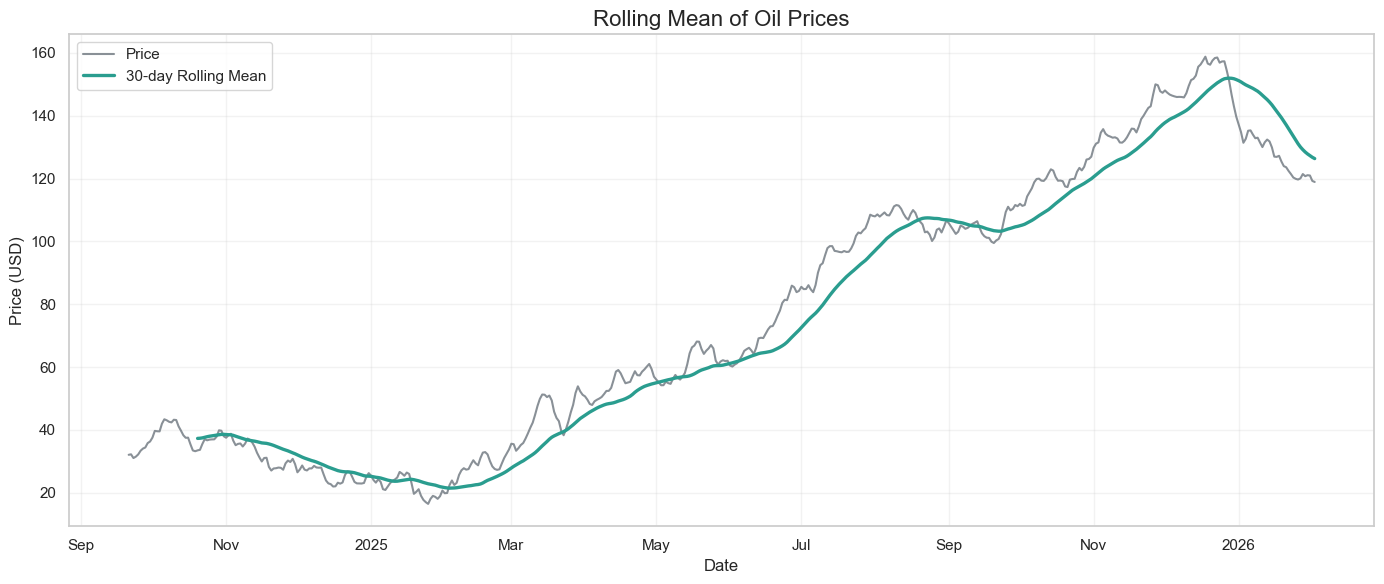

In [57]:
# Plot 4 — Rolling Mean
"""
Purpose:
Plot the rolling mean to assess whether the average level of the series changes over time.
A changing rolling mean is visual evidence that the original series is not stationary in mean.
"""

window = 30
roll_mean = df["price"].rolling(window=window).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["price"], color=COL["grey"], linewidth=1.5, alpha=0.8, label="Price")
ax.plot(
    df.index,
    roll_mean,
    color=COL["green"],
    linewidth=2.4,
    label=f"{window}-day Rolling Mean"
)

ax.set_title("Rolling Mean of Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "04_rolling_mean", FIG_DIR)

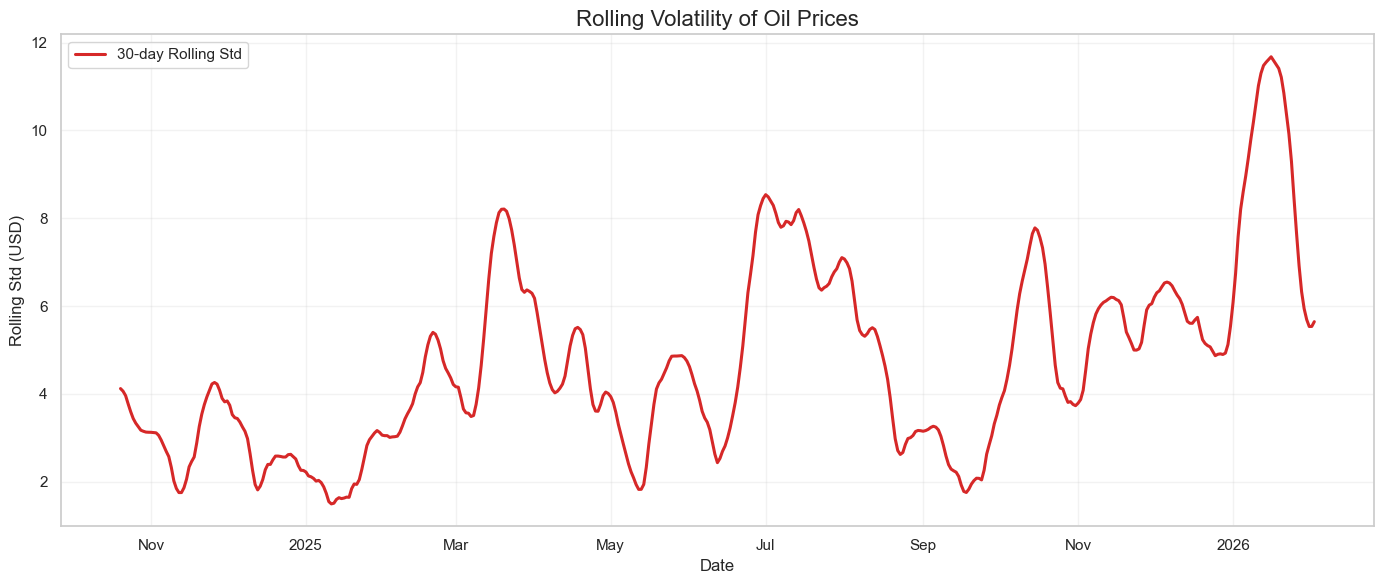

In [58]:
# Plot 5 — Rolling Volatility (Standard Deviation)
"""
Purpose:
Plot the rolling standard deviation of the raw price series to examine whether volatility
changes over time. Time-varying volatility suggests heteroskedasticity, which matters for
model diagnostics and forecast uncertainty interpretation.
"""

window = 30
roll_std = df["price"].rolling(window=window).std()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df.index,
    roll_std,
    color=COL["red"],
    linewidth=2.2,
    label=f"{window}-day Rolling Std"
)

ax.set_title("Rolling Volatility of Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "05_rolling_volatility", FIG_DIR)


In [59]:
# Step 5 — Log Transform and Return Series
"""
Purpose:
Create log(price), simple returns, and log-returns to explore variance stabilisation and stationarity.
These transformed series provide stronger evidence for modelling choices and support deeper EDA.
"""

if (df["price"] <= 0).any():
    raise ValueError("Non-positive values detected. Log transformation is not valid.")

log_price = np.log(df["price"])
simple_return = df["price"].pct_change().dropna()
log_return = log_price.diff().dropna()

print("Log-return summary statistics:")
print(log_return.describe())

print("\nSimple-return summary statistics:")
print(simple_return.describe())

Log-return summary statistics:
count    499.000000
mean       0.002624
std        0.030815
min       -0.159364
25%       -0.010784
50%        0.002483
75%        0.017907
max        0.119842
Name: price, dtype: float64

Simple-return summary statistics:
count    499.000000
mean       0.003101
std        0.030742
min       -0.147314
25%       -0.010726
50%        0.002486
75%        0.018068
max        0.127318
Name: price, dtype: float64


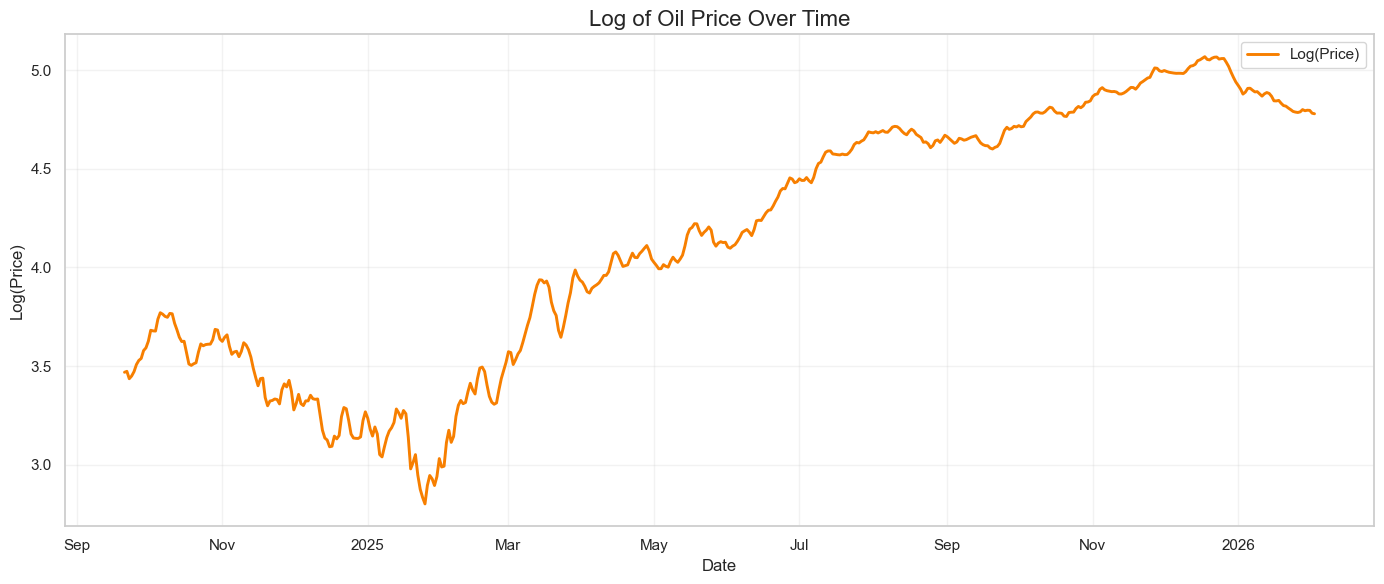

In [60]:
# Plot 6 — Log of Oil Price
"""
Purpose:
Plot the logarithm of price to assess whether the series looks more stable on a transformed scale.
This helps evaluate whether variance depends on the level of the original series.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    log_price.index,
    log_price,
    color=COL["orange"],
    linewidth=2.1,
    label="Log(Price)"
)

ax.set_title("Log of Oil Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Log(Price)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "06_log_price", FIG_DIR)

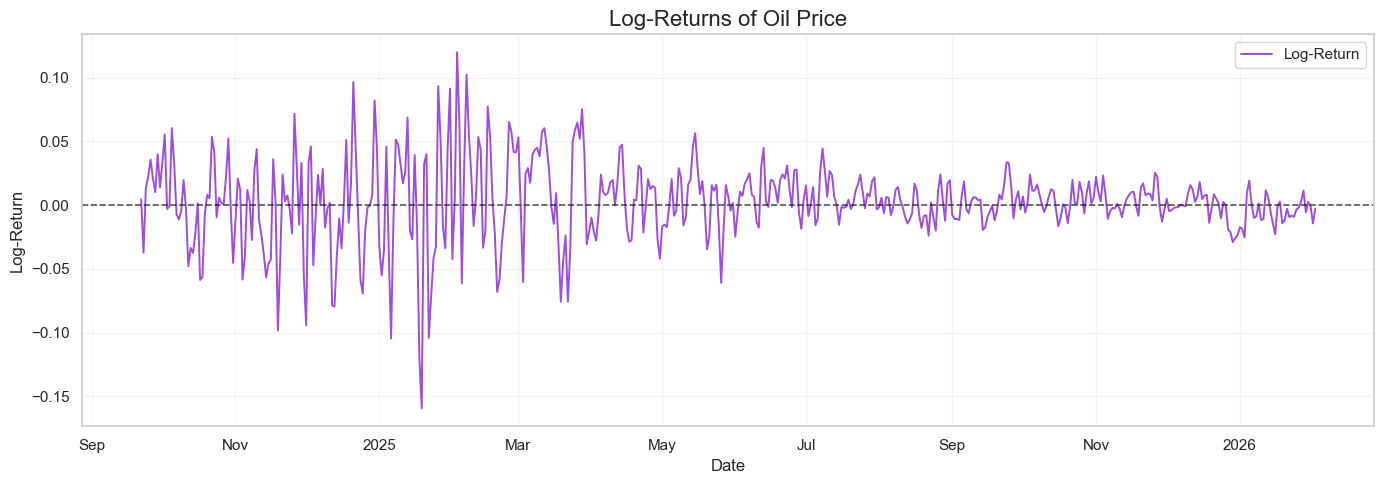

In [61]:
# Plot 7 — Log-Returns
"""
Purpose:
Visualise log-returns, which often fluctuate around a more stable mean than raw prices.
This plot also helps identify volatility clustering and unusual movement periods.
"""

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    log_return.index,
    log_return,
    color=COL["purple"],
    linewidth=1.4,
    label="Log-Return"
)
ax.axhline(0, color=COL["black"], linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_title("Log-Returns of Oil Price")
ax.set_xlabel("Date")
ax.set_ylabel("Log-Return")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "07_log_returns", FIG_DIR)

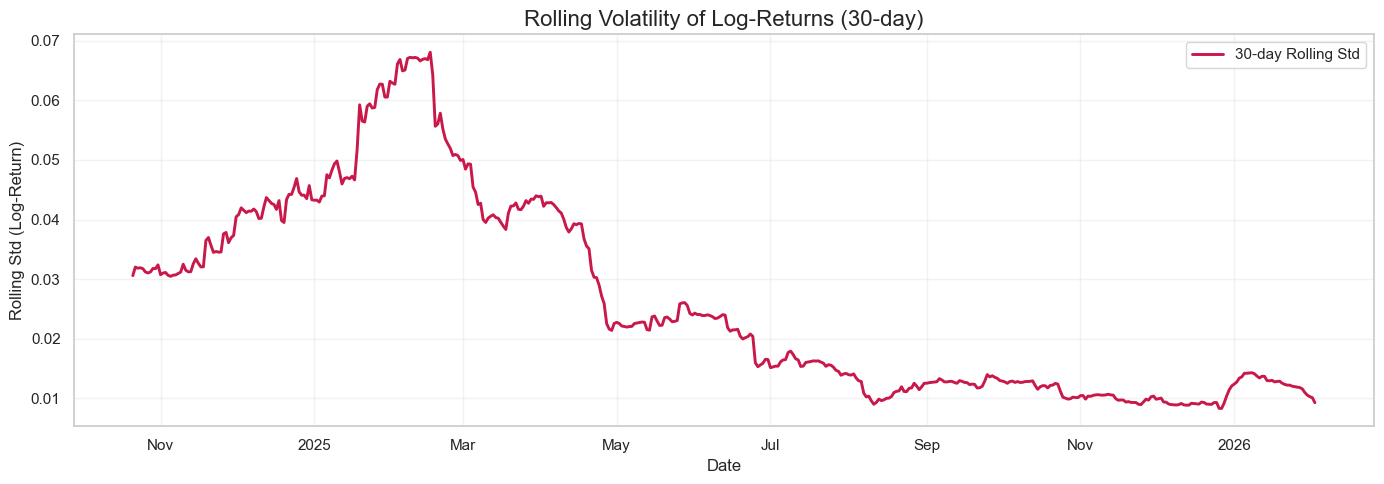

In [62]:
# Plot 8 — Rolling Volatility of Log-Returns
"""
Purpose:
Examine the rolling volatility of log-returns to assess volatility clustering directly.
This supports later critical discussion and possible future improvements such as ARCH/GARCH.
"""

ret_window = 30
roll_ret_std = log_return.rolling(ret_window).std()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    roll_ret_std.index,
    roll_ret_std,
    color=COL["rose"],
    linewidth=2.1,
    label=f"{ret_window}-day Rolling Std"
)

ax.set_title(f"Rolling Volatility of Log-Returns ({ret_window}-day)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std (Log-Return)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "08_log_return_volatility", FIG_DIR)

C:\Users\girid\AppData\Local\Temp\ipykernel_37088\493757319.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df["price"].resample("M").mean()   # more widely compatible than "ME"


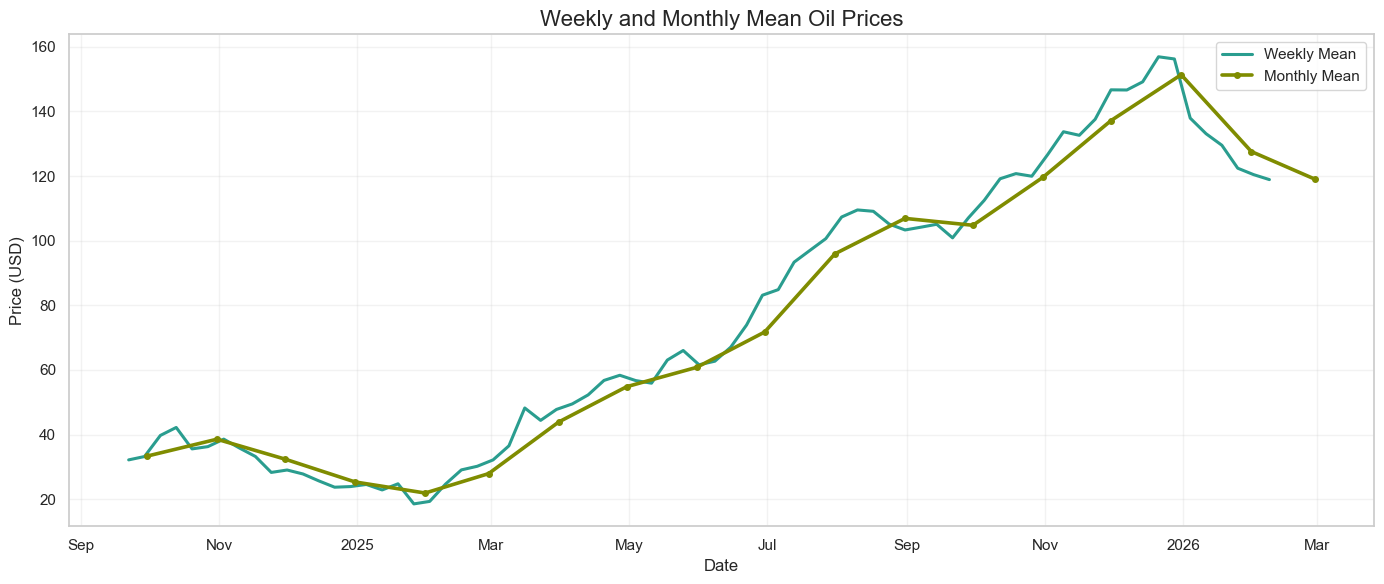

In [63]:
# Plot 9 — Weekly and Monthly Mean Prices
"""
Purpose:
Aggregate the daily series into weekly and monthly averages to reveal broader movement patterns.
This reduces short-term noise and makes medium-term shifts easier to interpret in the report.
"""

weekly = df["price"].resample("W").mean()
monthly = df["price"].resample("M").mean()   # more widely compatible than "ME"

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    weekly.index,
    weekly,
    color=COL["green"],
    linewidth=2.2,
    label="Weekly Mean"
)

ax.plot(
    monthly.index,
    monthly,
    color=COL["olive"],
    linewidth=2.6,
    marker="o",
    markersize=4,
    label="Monthly Mean"
)

ax.set_title("Weekly and Monthly Mean Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "09_weekly_monthly_means", FIG_DIR)

In [64]:
# Step 6 — Structural Shift Commentary
"""
Purpose:
Print a short structural interpretation based on the observed level shifts and volatility changes.
This helps support critical discussion in the report and acknowledges possible regime changes in the series.
"""

print("Structural interpretation:")
print("- The series shows clear changes in level over time, suggesting possible regime shifts.")
print("- These shifts reduce the realism of assuming one stable data-generating process across the full sample.")
print("- This can weaken long-horizon forecast reliability because one linear model may not capture all phases equally well.")
print("- This should be discussed as a limitation in the final report.")

Structural interpretation:
- The series shows clear changes in level over time, suggesting possible regime shifts.
- These shifts reduce the realism of assuming one stable data-generating process across the full sample.
- This can weaken long-horizon forecast reliability because one linear model may not capture all phases equally well.
- This should be discussed as a limitation in the final report.


In [65]:
# Step 7 — Stationarity Tests: ADF and KPSS
"""
Purpose:
Apply complementary stationarity tests to the original and transformed series.
ADF tests for a unit root, while KPSS tests for stationarity, providing stronger evidence together than either test alone.
"""

def adf_test(series, name="series", regression="c"):
    """
    Run the Augmented Dickey-Fuller test.

    Null hypothesis (H0):
    The series has a unit root and is non-stationary.
    """
    series = pd.Series(series).dropna()

    if len(series) < 10:
        raise ValueError(f"Series '{name}' is too short for a reliable ADF test.")

    stat, p, used_lag, nobs, crit, _ = adfuller(
        series,
        autolag="AIC",
        regression=regression
    )

    return {
        "name": name,
        "regression": regression,
        "nobs": int(nobs),
        "used_lag": int(used_lag),
        "ADF Statistic": float(stat),
        "p-value": float(p),
        "1%": float(crit["1%"]),
        "5%": float(crit["5%"]),
        "10%": float(crit["10%"])
    }


def kpss_test(series, name="series", regression="c"):
    """
    Run the KPSS test.

    Null hypothesis (H0):
    The series is stationary.
    """
    series = pd.Series(series).dropna()

    if len(series) < 10:
        raise ValueError(f"Series '{name}' is too short for a reliable KPSS test.")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, crit = kpss(series, regression=regression, nlags="auto")

    return {
        "name": name,
        "regression": regression,
        "nobs": int(len(series)),
        "lags": int(lags),
        "KPSS Statistic": float(stat),
        "p-value": float(p),
        "1%": float(crit["1%"]),
        "5%": float(crit["5%"]),
        "10%": float(crit["10%"])
    }


# First difference for stationarity testing and later ARIMA work
diff1 = df["price"].diff().dropna()

adf_results = pd.DataFrame([
    adf_test(df["price"], "Price (Original)", regression="c"),
    adf_test(df["price"], "Price (Original)", regression="ct"),
    adf_test(diff1, "Price (1st Difference)", regression="c"),
    adf_test(log_return, "Log-Returns", regression="c")
]).round(6)

kpss_results = pd.DataFrame([
    kpss_test(df["price"], "Price (Original)", regression="c"),
    kpss_test(df["price"], "Price (Original)", regression="ct"),
    kpss_test(diff1, "Price (1st Difference)", regression="c"),
    kpss_test(log_return, "Log-Returns", regression="c")
]).round(6)

print("ADF Results:")
display(adf_results)

print("KPSS Results:")
display(kpss_results)

ADF Results:


,name,regression,nobs,used_lag,ADF Statistic,p-value,1%,5%,10%
0,Price (Original),c,482,17,-0.546234,0.882674,-3.443990,-2.867555,-2.569974
1,Price (Original),ct,482,17,-2.361571,0.400238,-3.977676,-3.419638,-3.132431
2,Price (1st Difference),c,482,16,-4.541460,0.000165,-3.443990,-2.867555,-2.569974
3,Log-Returns,c,485,13,-6.341003,0.000000,-3.443905,-2.867518,-2.569954


KPSS Results:


,name,regression,nobs,lags,KPSS Statistic,p-value,1%,5%,10%
0,Price (Original),c,500,12,3.705619,0.01,0.739,0.463,0.347
1,Price (Original),ct,500,12,0.462936,0.01,0.216,0.146,0.119
2,Price (1st Difference),c,499,8,0.190341,0.10,0.739,0.463,0.347
3,Log-Returns,c,499,6,0.130493,0.10,0.739,0.463,0.347


In [66]:
# Step 8 — Stationarity Interpretation
"""
Purpose:
Provide concise, decision-oriented interpretations of the stationarity tests so the notebook
connects the evidence directly to ARIMA differencing choices.
"""

orig_adf_c_p = adf_results.loc[
    (adf_results["name"] == "Price (Original)") & (adf_results["regression"] == "c"),
    "p-value"
].iloc[0]

orig_adf_ct_p = adf_results.loc[
    (adf_results["name"] == "Price (Original)") & (adf_results["regression"] == "ct"),
    "p-value"
].iloc[0]

orig_kpss_c_p = kpss_results.loc[
    (kpss_results["name"] == "Price (Original)") & (kpss_results["regression"] == "c"),
    "p-value"
].iloc[0]

orig_kpss_ct_p = kpss_results.loc[
    (kpss_results["name"] == "Price (Original)") & (kpss_results["regression"] == "ct"),
    "p-value"
].iloc[0]

diff_adf_p = adf_results.loc[
    adf_results["name"] == "Price (1st Difference)",
    "p-value"
].iloc[0]

diff_kpss_p = kpss_results.loc[
    kpss_results["name"] == "Price (1st Difference)",
    "p-value"
].iloc[0]

print("Original series interpretation:")
if orig_adf_c_p >= 0.05 and orig_kpss_c_p < 0.05:
    print("- With a constant only, ADF and KPSS both indicate non-stationarity in the raw price series.")
else:
    print("- The constant-only tests are mixed, so the raw price series is not safely treated as stationary.")

if orig_adf_ct_p < 0.05 and orig_kpss_ct_p >= 0.05:
    print("- With a deterministic trend included, the series may be trend-stationary.")
    print("- However, the level series is still not appropriate for plain ARMA because the mean is not stable around a constant level.")
else:
    print("- Even allowing for a deterministic trend, the raw series is not convincingly stationary enough for plain ARMA.")

print("\nFirst-difference interpretation:")
if diff_adf_p < 0.05 and diff_kpss_p >= 0.05:
    print("- The first-differenced series is supported as stationary by both ADF and KPSS.")
    print("- Therefore d = 1 is the primary differencing candidate for ARIMA.")
    print("- Any d = 2 model must outperform d = 1 convincingly and should be checked for over-differencing risk.")
else:
    print("- The first-differenced series is not fully validated as stationary, so d = 2 may still need consideration.")

Original series interpretation:
- With a constant only, ADF and KPSS both indicate non-stationarity in the raw price series.
- Even allowing for a deterministic trend, the raw series is not convincingly stationary enough for plain ARMA.

First-difference interpretation:
- The first-differenced series is supported as stationary by both ADF and KPSS.
- Therefore d = 1 is the primary differencing candidate for ARIMA.
- Any d = 2 model must outperform d = 1 convincingly and should be checked for over-differencing risk.


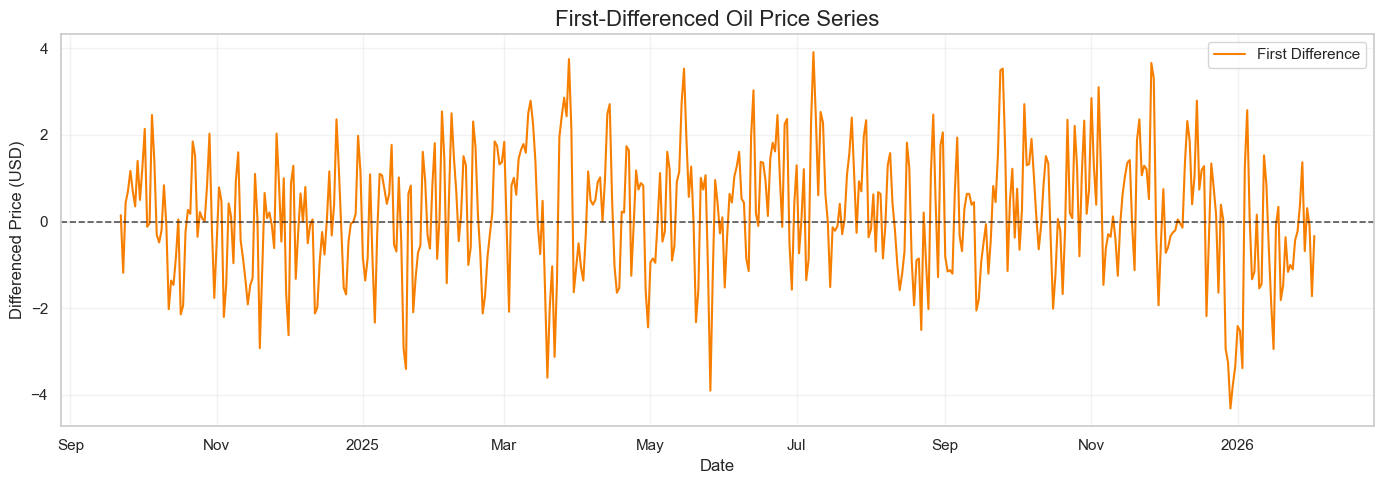

In [67]:
# Plot 10 — First-Differenced Series
"""
Purpose:
Plot the first-differenced series to visually assess whether differencing has stabilised the mean.
This figure supports the transition from the raw series to ARIMA-based modelling.
"""

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    diff1.index,
    diff1,
    color=COL["orange"],
    linewidth=1.5,
    label="First Difference"
)
ax.axhline(0, color=COL["black"], linestyle="--", linewidth=1.2, alpha=0.7)

ax.set_title("First-Differenced Oil Price Series")
ax.set_xlabel("Date")
ax.set_ylabel("Differenced Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "10_first_difference", FIG_DIR)

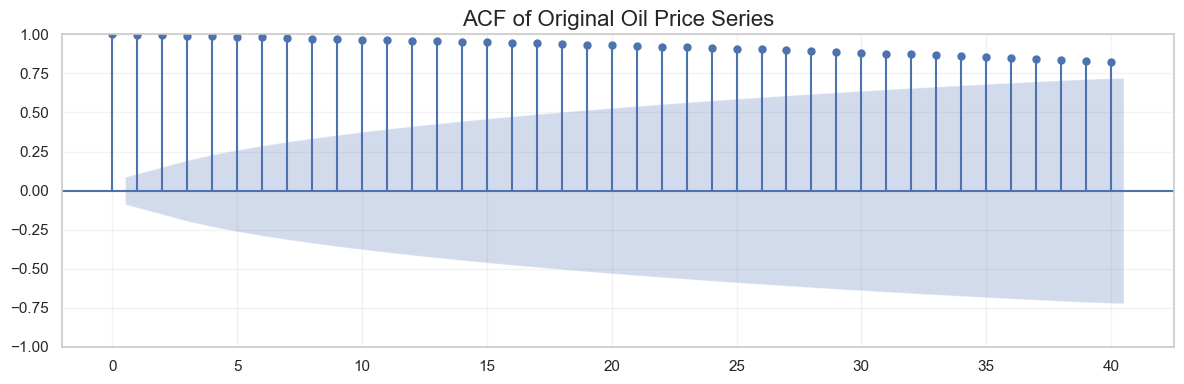

In [68]:
# Plot 11 — ACF of Original Series
"""
Purpose:
Show the autocorrelation structure of the original price series.
Persistent autocorrelation across many lags is consistent with non-stationarity and trending behaviour.
"""

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(df["price"].dropna(), lags=40, ax=ax)
ax.set_title("ACF of Original Oil Price Series")

save_and_show(fig, "11_acf_original", FIG_DIR)

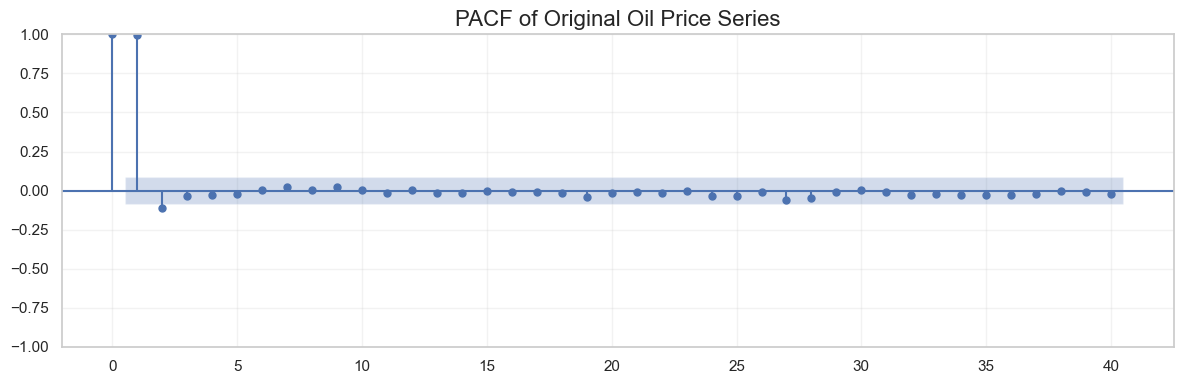

In [69]:
# Plot 12 — PACF of Original Series
"""
Purpose:
Show the partial autocorrelation structure of the original price series.
This helps describe lag dependence before differencing and supports model discussion in the report.
"""

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df["price"].dropna(), lags=40, ax=ax, method="ywm")
ax.set_title("PACF of Original Oil Price Series")

save_and_show(fig, "12_pacf_original", FIG_DIR)


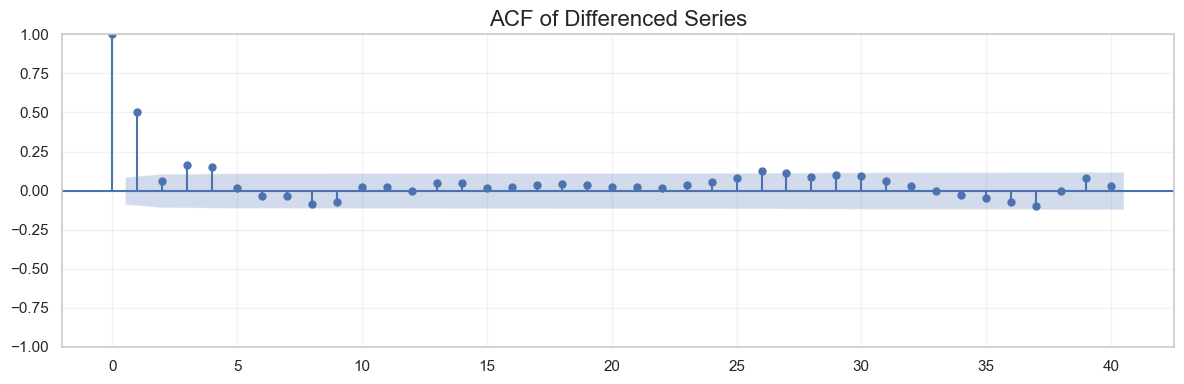

In [70]:
# Plot 13 — ACF of Differenced Series
"""
Purpose:
Plot the ACF of the differenced series to help identify plausible moving average behaviour.
This is useful for interpreting ARIMA order selection alongside the AIC grid search.
"""

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(diff1.dropna(), lags=40, ax=ax)
ax.set_title("ACF of Differenced Series")

save_and_show(fig, "13_acf_differenced", FIG_DIR)

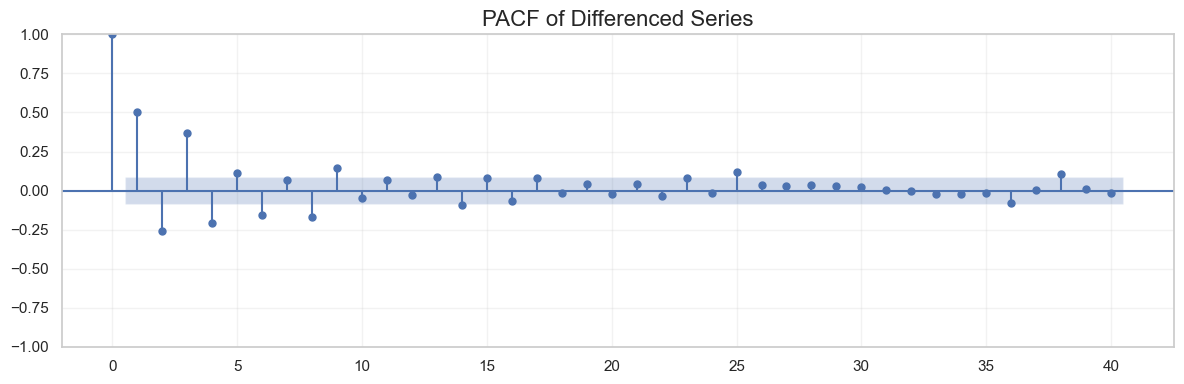

In [71]:
# Plot 14 — PACF of Differenced Series
"""
Purpose:
Plot the PACF of the differenced series to help identify plausible autoregressive behaviour.
This gives visual support for ARIMA order choices even though final selection is done by grid search.
"""

fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(diff1.dropna(), lags=40, ax=ax, method="ywm")
ax.set_title("PACF of Differenced Series")

save_and_show(fig, "14_pacf_differenced", FIG_DIR)

In [72]:
# Define main series, train/test split, and baseline forecasts

series = df["price"].copy().dropna()

split_idx = int(len(series) * 0.8)

train = series.iloc[:split_idx].copy()
test = series.iloc[split_idx:].copy()

# Baseline 1: Naive forecast
naive_fc = pd.Series(train.iloc[-1], index=test.index)

# Baseline 2: Mean forecast
mean_fc = pd.Series(train.mean(), index=test.index)

# Baseline 3: Random walk with drift
drift = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_fc = pd.Series(
    train.iloc[-1] + drift * np.arange(1, len(test) + 1),
    index=test.index
)

print(f"Series length: {len(series)}")
print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Series length: 500
Train size: 400
Test size: 100


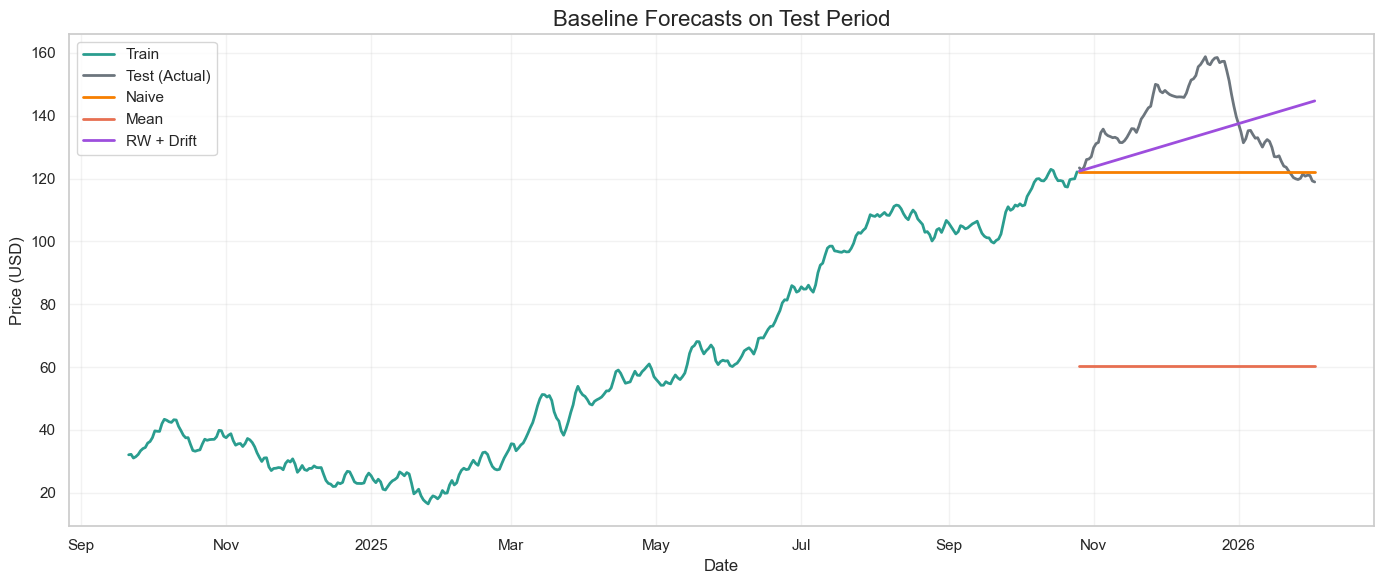

In [73]:
# Plot 15 — Baseline Forecast Comparison on Test Set
"""
Purpose:
Visualise baseline forecasts against the actual test period to provide intuitive benchmark comparisons.
This helps show whether ARIMA adds value beyond very simple forecasting strategies.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color=COL["green"], linewidth=2.0, label="Train")
ax.plot(test.index, test, color=COL["grey"], linewidth=2.0, label="Test (Actual)")
ax.plot(test.index, naive_fc, color=COL["orange"], linewidth=2.0, label="Naive")
ax.plot(test.index, mean_fc, color=COL["pink"], linewidth=2.0, label="Mean")
ax.plot(test.index, drift_fc, color=COL["purple"], linewidth=2.0, label="RW + Drift")

ax.set_title("Baseline Forecasts on Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "15_baseline_forecasts", FIG_DIR)

In [74]:
# Step 11 — Full ARIMA Grid Search + Train-Only Model Selection
"""
Purpose:
Run the full required ARIMA grid search over p=0..8, d=0..2, q=0..8 using TRAINING DATA ONLY.
The final ARIMA order is selected without using the test set, which avoids test leakage.

Selection logic:
1. Run the full grid search on the training set.
2. Keep only converged models.
3. Build a principled shortlist from the best AIC/BIC candidates.
4. Refit shortlisted models on training data only and inspect residual diagnostics.
5. Select the final model using train-only evidence:
   - prefer residual white-noise behaviour where possible
   - then prefer lower differencing when effectively tied
   - then prefer lower AIC/BIC
"""

ARIMA_MAXITER = 40
ARIMA_FINAL_MAXITER = 80
ARIMA_SHORTLIST_TOP = 12
AIC_TOL = 2.0  # standard practical threshold for "effectively tied" AIC models


def fit_arima_once(series, order, maxiter=ARIMA_MAXITER):
    """Fit one ARIMA model once using bounded iterations."""
    order = tuple(int(x) for x in order)
    series = pd.Series(series).dropna()

    model = ARIMA(
        series,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(method_kwargs={"maxiter": int(maxiter)})


def arima_grid_search_fast(train_series,
                           p_range=range(0, 9),
                           d_range=range(0, 3),
                           q_range=range(0, 9),
                           top_n=ARIMA_SHORTLIST_TOP):
    """
    Run the full required ARIMA grid search and store only lightweight results.
    """
    train_series = pd.Series(train_series).dropna()

    rows = []
    failures = []
    attempted = 0
    success = 0
    start_time = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for d in d_range:
            print(f"Running grid search for d={d} ...")
            for p in p_range:
                for q in q_range:
                    attempted += 1
                    order = (int(p), int(d), int(q))

                    try:
                        fit = fit_arima_once(train_series, order, maxiter=ARIMA_MAXITER)
                        success += 1

                        try:
                            converged = bool(fit.mle_retvals.get("converged", True))
                        except Exception:
                            converged = True

                        rows.append({
                            "p": int(p),
                            "d": int(d),
                            "q": int(q),
                            "order": order,
                            "aic": float(fit.aic),
                            "bic": float(fit.bic),
                            "llf": float(fit.llf),
                            "converged": converged
                        })

                    except Exception as e:
                        failures.append({
                            "p": int(p),
                            "d": int(d),
                            "q": int(q),
                            "order": order,
                            "error": str(e)
                        })

    elapsed = time.time() - start_time

    results_df = pd.DataFrame(rows)
    fail_df = pd.DataFrame(failures)

    if results_df.empty:
        raise RuntimeError(
            "No ARIMA models fitted successfully. Inspect fail_df for fitting errors."
        )

    results_aic = results_df.sort_values("aic").reset_index(drop=True)
    results_bic = results_df.sort_values("bic").reset_index(drop=True)

    converged_df = (
        results_df.loc[results_df["converged"]]
        .copy()
        .sort_values("aic")
        .reset_index(drop=True)
    )

    if converged_df.empty:
        raise RuntimeError("No converged ARIMA models were found.")

    best_aic_order = tuple(results_aic.iloc[0][["p", "d", "q"]].astype(int))
    best_bic_order = tuple(results_bic.iloc[0][["p", "d", "q"]].astype(int))
    best_converged_aic_order = tuple(converged_df.iloc[0][["p", "d", "q"]].astype(int))
    best_converged_bic_order = tuple(
        converged_df.sort_values("bic").iloc[0][["p", "d", "q"]].astype(int)
    )

    top_df = converged_df.head(top_n).copy()
    top_df["order"] = top_df.apply(lambda r: f"({int(r.p)},{int(r.d)},{int(r.q)})", axis=1)
    top_df = top_df[["order", "aic", "bic", "llf", "converged"]]

    summary = {
        "attempted": attempted,
        "success": success,
        "failed": attempted - success,
        "converged_true": int(results_df["converged"].sum()),
        "converged_false": int((~results_df["converged"]).sum()),
        "elapsed_seconds": elapsed
    }

    return (
        results_df,
        results_aic,
        results_bic,
        converged_df,
        best_aic_order,
        best_bic_order,
        best_converged_aic_order,
        best_converged_bic_order,
        top_df,
        fail_df,
        summary
    )


def diagnose_arima_candidate_trainonly(train_series, order, lb_lags=(10, 20, 30), maxiter=ARIMA_FINAL_MAXITER):
    """
    Refit one shortlisted ARIMA model on the training set only and compute diagnostics.
    No test-set information is used here.
    """
    order = tuple(int(x) for x in order)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = fit_arima_once(train_series, order, maxiter=maxiter)

    resid = fit.resid.dropna()
    usable_lags = [lag for lag in lb_lags if lag < len(resid)]

    if len(usable_lags) == 0:
        lb_min_p = np.nan
        lb_all_ok = False
    else:
        lb = acorr_ljungbox(resid, lags=usable_lags, return_df=True)
        lb_min_p = float(lb["lb_pvalue"].min())
        lb_all_ok = bool((lb["lb_pvalue"] > 0.05).all())

    if resid.std(ddof=0) == 0:
        arch_pvalue = np.nan
    else:
        std_resid = (resid - resid.mean()) / resid.std(ddof=0)
        _, arch_pvalue, _, _ = het_arch(std_resid)

    return {
        "order": order,
        "aic": float(fit.aic),
        "bic": float(fit.bic),
        "lb_min_pvalue": lb_min_p,
        "lb_all_ok": lb_all_ok,
        "arch_pvalue": float(arch_pvalue) if pd.notna(arch_pvalue) else np.nan,
        "fit": fit
    }


(
    results_train_df,
    results_aic,
    results_bic,
    converged_results_df,
    best_aic_order,
    best_bic_order,
    best_converged_aic_order,
    best_converged_bic_order,
    top_train_models,
    fail_df,
    search_summary
) = arima_grid_search_fast(
    train_series=train,
    p_range=range(0, 9),
    d_range=range(0, 3),
    q_range=range(0, 9),
    top_n=ARIMA_SHORTLIST_TOP
)

print("\nGrid search summary:")
print(f"Attempted models:        {search_summary['attempted']}")
print(f"Successful fits:         {search_summary['success']}")
print(f"Failed fits:             {search_summary['failed']}")
print(f"Converged fits:          {search_summary['converged_true']}")
print(f"Non-converged fits:      {search_summary['converged_false']}")
print(f"Elapsed time (seconds):  {search_summary['elapsed_seconds']:.2f}")
print(f"Best order by AIC:       {best_aic_order}")
print(f"Best order by BIC:       {best_bic_order}")
print(f"Best converged by AIC:   {best_converged_aic_order}")
print(f"Best converged by BIC:   {best_converged_bic_order}")

print("\nTop converged models by AIC:")
display(top_train_models)

# Build a principled shortlist from train-only evidence
candidate_orders = []
candidate_orders += [tuple(map(int, x)) for x in converged_results_df.head(8)[["p", "d", "q"]].to_numpy()]
candidate_orders.append(tuple(map(int, best_converged_bic_order)))

best_d1 = converged_results_df.loc[converged_results_df["d"] == 1].head(5)
candidate_orders += [tuple(map(int, x)) for x in best_d1[["p", "d", "q"]].to_numpy()]

best_d0 = converged_results_df.loc[converged_results_df["d"] == 0].head(3)
candidate_orders += [tuple(map(int, x)) for x in best_d0[["p", "d", "q"]].to_numpy()]

best_d2 = converged_results_df.loc[converged_results_df["d"] == 2].head(3)
candidate_orders += [tuple(map(int, x)) for x in best_d2[["p", "d", "q"]].to_numpy()]

candidate_orders = list(dict.fromkeys(candidate_orders))
print(f"\nShortlisted converged candidate orders: {candidate_orders}")

candidate_diagnostics = []
candidate_failures = []

for order in candidate_orders:
    try:
        candidate_diagnostics.append(
            diagnose_arima_candidate_trainonly(train, order, lb_lags=(10, 20, 30), maxiter=ARIMA_FINAL_MAXITER)
        )
    except Exception as e:
        candidate_failures.append({"order": order, "error": str(e)})

candidate_diag_df = pd.DataFrame([
    {
        "order": r["order"],
        "aic": r["aic"],
        "bic": r["bic"],
        "lb_min_pvalue": r["lb_min_pvalue"],
        "lb_all_ok": r["lb_all_ok"],
        "arch_pvalue": r["arch_pvalue"]
    }
    for r in candidate_diagnostics
]).copy()

if candidate_diag_df.empty:
    print("\nWarning: shortlisted train-only diagnostic evaluation failed completely.")
    print("Falling back to best converged AIC model.")
    SELECTED_ORDER = tuple(map(int, best_converged_aic_order))
else:
    candidate_diag_df["d"] = candidate_diag_df["order"].apply(lambda x: x[1])
    candidate_diag_df = candidate_diag_df.sort_values(["aic", "bic"]).reset_index(drop=True)

    best_aic_value = candidate_diag_df["aic"].min()
    eligible_df = candidate_diag_df.loc[candidate_diag_df["aic"] <= best_aic_value + AIC_TOL].copy()

    # Prefer residual-white-noise models if at least one exists
    if eligible_df["lb_all_ok"].any():
        eligible_df = eligible_df.loc[eligible_df["lb_all_ok"]].copy()

    # Prefer lower differencing among effectively tied models
    eligible_df = eligible_df.sort_values(["d", "aic", "bic"]).reset_index(drop=True)

    SELECTED_ORDER = tuple(map(int, eligible_df.iloc[0]["order"]))

    print("\nTrain-only ARIMA candidate comparison:")
    display(candidate_diag_df.round(6))

print("\nFinal ARIMA selection rule applied:")
print("- full p=0..8, d=0..2, q=0..8 grid search completed")
print("- only converged models considered for final choice")
print("- final order selected using TRAINING DATA ONLY")
print("- residual autocorrelation preferred to be insignificant where possible")
print("- lower differencing preferred when AIC values are effectively tied")
print(f"Selected final ARIMA order: {SELECTED_ORDER}")

if len(candidate_failures) > 0:
    print("\nShortlist diagnostic failures:")
    display(pd.DataFrame(candidate_failures))

if not fail_df.empty:
    print("\nSample grid-search fitting failures (first 10):")
    display(fail_df.head(10))

Running grid search for d=0 ...
Running grid search for d=1 ...
Running grid search for d=2 ...

Grid search summary:
Attempted models:        243
Successful fits:         243
Failed fits:             0
Converged fits:          124
Non-converged fits:      119
Elapsed time (seconds):  371.91
Best order by AIC:       (4, 2, 8)
Best order by BIC:       (0, 2, 2)
Best converged by AIC:   (0, 2, 8)
Best converged by BIC:   (0, 2, 2)

Top converged models by AIC:


,order,aic,bic,llf,converged
0,"(0,2,8)",1106.682994,1142.355209,-544.341497,True
1,"(0,2,7)",1108.863415,1140.592589,-546.431708,True
2,"(8,2,2)",1108.875583,1152.503197,-543.437791,True
3,"(0,1,7)",1109.827829,1141.577490,-546.913915,True
4,"(8,2,3)",1110.268359,1157.862120,-543.134179,True
5,"(0,2,6)",1110.362092,1138.143045,-548.181046,True
6,"(0,1,8)",1110.369275,1146.064595,-546.184637,True
7,"(1,1,7)",1111.387793,1147.106161,-546.693896,True
8,"(8,1,1)",1111.892930,1151.580006,-545.946465,True
9,"(0,1,6)",1112.185273,1139.984106,-549.092636,True



Shortlisted converged candidate orders: [(0, 2, 8), (0, 2, 7), (8, 2, 2), (0, 1, 7), (8, 2, 3), (0, 2, 6), (0, 1, 8), (1, 1, 7), (0, 2, 2), (8, 1, 1), (0, 1, 6), (2, 0, 8), (1, 0, 5), (3, 0, 7)]

Train-only ARIMA candidate comparison:


,order,aic,bic,lb_min_pvalue,lb_all_ok,arch_pvalue,d
0,"(0, 2, 8)",1106.682994,1142.355209,0.000000,False,0.988526,2
1,"(0, 2, 7)",1108.863415,1140.592589,0.000000,False,0.986056,2
2,"(8, 2, 2)",1108.875583,1152.503197,0.000000,False,0.994438,2
3,"(0, 1, 7)",1109.827829,1141.577490,0.999859,True,0.996993,1
4,"(8, 2, 3)",1110.268359,1157.862120,0.000000,False,0.994005,2
5,"(0, 2, 6)",1110.362092,1138.143045,0.000000,False,0.985246,2
6,"(0, 1, 8)",1110.369275,1146.064595,0.999964,True,0.996670,1
7,"(1, 1, 7)",1111.387793,1147.106161,0.054229,True,0.993011,1
8,"(8, 1, 1)",1111.892930,1151.580006,0.982613,True,0.994270,1
9,"(0, 1, 6)",1112.185273,1139.984106,0.999710,True,0.993192,1



Final ARIMA selection rule applied:
- full p=0..8, d=0..2, q=0..8 grid search completed
- only converged models considered for final choice
- final order selected using TRAINING DATA ONLY
- residual autocorrelation preferred to be insignificant where possible
- lower differencing preferred when AIC values are effectively tied
Selected final ARIMA order: (0, 2, 8)


In [75]:
# Step 12 — Fit the Selected ARIMA on Training Data and Evaluate on the Test Set
"""
Purpose:
Fit the final train-only-selected ARIMA model on the training data, evaluate it once on the untouched
test set, and summarise the model diagnostics used in the selection process.
"""

# -----------------------------
# Fit final ARIMA on training set
# -----------------------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arima_fit = ARIMA(
        train,
        order=SELECTED_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method_kwargs={"maxiter": 80})

print(arima_fit.summary())

# -----------------------------
# Test-set forecast from train-fitted model
# -----------------------------
arima_test_fc = arima_fit.get_forecast(steps=len(test))
arima_test_mean = pd.Series(arima_test_fc.predicted_mean, index=test.index)
arima_test_ci = arima_test_fc.conf_int(alpha=0.05)
arima_test_ci.index = test.index

# Standardise CI column names defensively
arima_test_ci.columns = ["lower", "upper"]

# -----------------------------
# Test metrics
# -----------------------------
rmse_arima, mae_arima = compute_metrics(test, arima_test_mean)
rmse_arima_pct = 100 * rmse_arima / series.mean()

print("\nFinal ARIMA Test Performance:")
print(f"Selected ARIMA order: {SELECTED_ORDER}")
print(f"ARIMA RMSE: {rmse_arima:.4f}")
print(f"ARIMA MAE:  {mae_arima:.4f}")
print(f"ARIMA RMSE as % of average price: {rmse_arima_pct:.2f}%")

# -----------------------------
# Show train-only shortlist diagnostics used for model selection
# -----------------------------
if "candidate_diag_df" in globals() and isinstance(candidate_diag_df, pd.DataFrame) and not candidate_diag_df.empty:
    print("\nTrain-only shortlisted candidate diagnostics:")
    display(candidate_diag_df.sort_values(["aic", "bic"]).reset_index(drop=True).round(6))

# -----------------------------
# Selected model row from converged grid-search results
# -----------------------------
if "converged_results_df" in globals() and not converged_results_df.empty:
    selected_row = converged_results_df.loc[
        (converged_results_df["p"] == SELECTED_ORDER[0]) &
        (converged_results_df["d"] == SELECTED_ORDER[1]) &
        (converged_results_df["q"] == SELECTED_ORDER[2])
    ].copy()

    if not selected_row.empty:
        print("\nSelected ARIMA model entry from converged grid search:")
        display(selected_row[["order", "aic", "bic", "llf", "converged"]].reset_index(drop=True).round(6))

print("\nMethod note:")
print("The final ARIMA order was selected using training data only.")
print("The test set was used exactly once here for final out-of-sample evaluation.")

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  400
Model:                 ARIMA(0, 2, 8)   Log Likelihood                -544.341
Date:                Wed, 11 Mar 2026   AIC                           1106.683
Time:                        10:08:22   BIC                           1142.355
Sample:                    09-21-2024   HQIC                          1120.825
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0722      0.087      0.832      0.405      -0.098       0.242
ma.L2         -1.1497      0.086    -13.338      0.000      -1.319      -0.981
ma.L3          0.0675      0.082      0.820      0.4

,order,aic,bic,lb_min_pvalue,lb_all_ok,arch_pvalue,d
0,"(0, 2, 8)",1106.682994,1142.355209,0.000000,False,0.988526,2
1,"(0, 2, 7)",1108.863415,1140.592589,0.000000,False,0.986056,2
2,"(8, 2, 2)",1108.875583,1152.503197,0.000000,False,0.994438,2
3,"(0, 1, 7)",1109.827829,1141.577490,0.999859,True,0.996993,1
4,"(8, 2, 3)",1110.268359,1157.862120,0.000000,False,0.994005,2
5,"(0, 2, 6)",1110.362092,1138.143045,0.000000,False,0.985246,2
6,"(0, 1, 8)",1110.369275,1146.064595,0.999964,True,0.996670,1
7,"(1, 1, 7)",1111.387793,1147.106161,0.054229,True,0.993011,1
8,"(8, 1, 1)",1111.892930,1151.580006,0.982613,True,0.994270,1
9,"(0, 1, 6)",1112.185273,1139.984106,0.999710,True,0.993192,1



Selected ARIMA model entry from converged grid search:


,order,aic,bic,llf,converged
0,"(0, 2, 8)",1106.682994,1142.355209,-544.341497,True



Method note:
The final ARIMA order was selected using training data only.
The test set was used exactly once here for final out-of-sample evaluation.


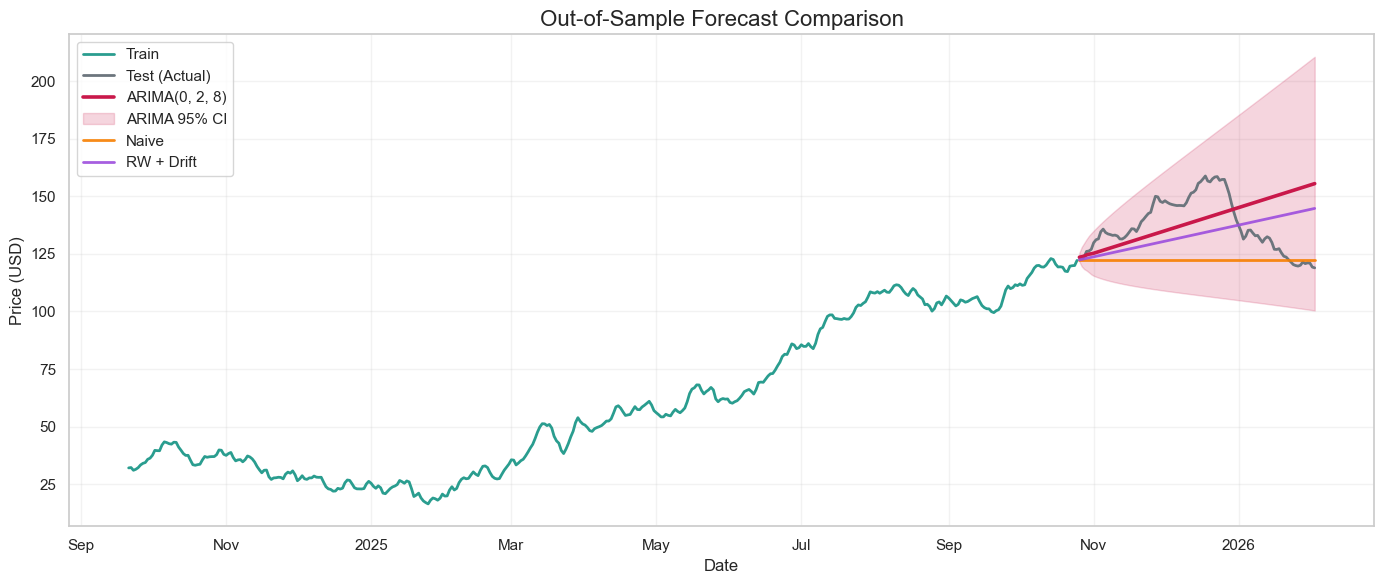

In [76]:
# Plot 16 — ARIMA vs Actual vs Baselines on Test Set
"""
Purpose:
Compare ARIMA forecasts against the actual test values and the baseline forecasts in one figure.
This plot is useful for discussing whether ARIMA captures the test-period behaviour more effectively than simpler methods.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color=COL["green"], linewidth=2.0, label="Train")
ax.plot(test.index, test, color=COL["grey"], linewidth=2.0, label="Test (Actual)")
ax.plot(
    arima_test_mean.index,
    arima_test_mean.values,
    color=COL["rose"],
    linewidth=2.6,
    label=f"ARIMA{SELECTED_ORDER}"
)

ax.fill_between(
    arima_test_ci.index,
    arima_test_ci["lower"].values,
    arima_test_ci["upper"].values,
    color=COL["rose"],
    alpha=0.18,
    label="ARIMA 95% CI"
)

ax.plot(test.index, naive_fc, color=COL["orange"], linewidth=2.0, alpha=0.9, label="Naive")
ax.plot(test.index, drift_fc, color=COL["purple"], linewidth=2.0, alpha=0.9, label="RW + Drift")

ax.set_title("Out-of-Sample Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "16_arima_vs_baselines_test", FIG_DIR)

In [78]:
# Step 14 — Prediction Interval Coverage on Test Set
"""
Purpose:
Evaluate whether the ARIMA 95% prediction intervals are reasonably calibrated on the test set.
This uses the already selected fitted ARIMA model to avoid unnecessary refitting.
"""
from statsmodels.tsa.arima.model import ARIMA

arima_train_fit = ARIMA(train, order=SELECTED_ORDER).fit()

print(f"ARIMA model fitted successfully with order {SELECTED_ORDER}")
print(arima_train_fit.summary())

fc_test = arima_train_fit.get_forecast(steps=len(test))
ci_test = fc_test.conf_int(alpha=0.05)

lower = ci_test.iloc[:, 0].values
upper = ci_test.iloc[:, 1].values
actual = test.values

covered = (actual >= lower) & (actual <= upper)
coverage_rate = float(covered.mean())

print(f"95% interval coverage on test set: {coverage_rate:.3%}")

if coverage_rate < 0.90:
    print("Prediction intervals appear too narrow relative to the observed test data.")
elif coverage_rate > 0.98:
    print("Prediction intervals may be overly wide.")
else:
    print("Prediction interval coverage appears reasonably calibrated.")

c:\Users\girid\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA model fitted successfully with order (0, 2, 8)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  400
Model:                 ARIMA(0, 2, 8)   Log Likelihood                -555.671
Date:                Wed, 11 Mar 2026   AIC                           1129.342
Time:                        10:09:21   BIC                           1165.220
Sample:                    09-21-2024   HQIC                          1143.553
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0398      0.052     -0.772      0.440      -0.141       0.061
ma.L2         -1.0019      0.053    -18.976      0.000      -1.105      -0.898

In [79]:
# Step 15 — Residual Diagnostics: Ljung-Box and ARCH Tests
"""
Purpose:
Test whether the residuals behave like white noise and whether residual variance is constant over time.
These formal diagnostics are essential for evaluating whether the final ARIMA model is statistically adequate.
"""

resid = arima_train_fit.resid.dropna()

if resid.std(ddof=0) == 0:
    raise ValueError("Residual standard deviation is zero; diagnostics cannot be interpreted reliably.")

std_resid = (resid - resid.mean()) / resid.std(ddof=0)

lb_lags = [lag for lag in [10, 20, 30] if lag < len(resid)]
if len(lb_lags) == 0:
    raise ValueError("Residual series is too short for Ljung-Box diagnostics at the chosen lags.")

lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
arch_stat, arch_pvalue, _, _ = het_arch(std_resid)

print("Ljung-Box test results:")
display(lb.round(6))

lb_ok = bool((lb["lb_pvalue"] > 0.05).all())
if lb_ok:
    print("Residuals behave like white noise at the tested lags.")
else:
    print("Residual autocorrelation still remains at one or more tested lags, so ARIMA is not fully adequate.")

print(f"ARCH test statistic: {arch_stat:.4f}")
print(f"ARCH test p-value:   {arch_pvalue:.6f}")

if arch_pvalue < 0.05:
    print("There is evidence of volatility clustering; this supports discussing ARIMA's constant-variance limitation.")
else:
    print("There is no strong evidence of ARCH-type heteroskedasticity in the standardised residuals.")

Ljung-Box test results:


,lb_stat,lb_pvalue
10,37.491872,0.000047
20,39.312337,0.006096
30,41.004921,0.086822


Residual autocorrelation still remains at one or more tested lags, so ARIMA is not fully adequate.
ARCH test statistic: 2.1907
ARCH test p-value:   0.994658
There is no strong evidence of ARCH-type heteroskedasticity in the standardised residuals.


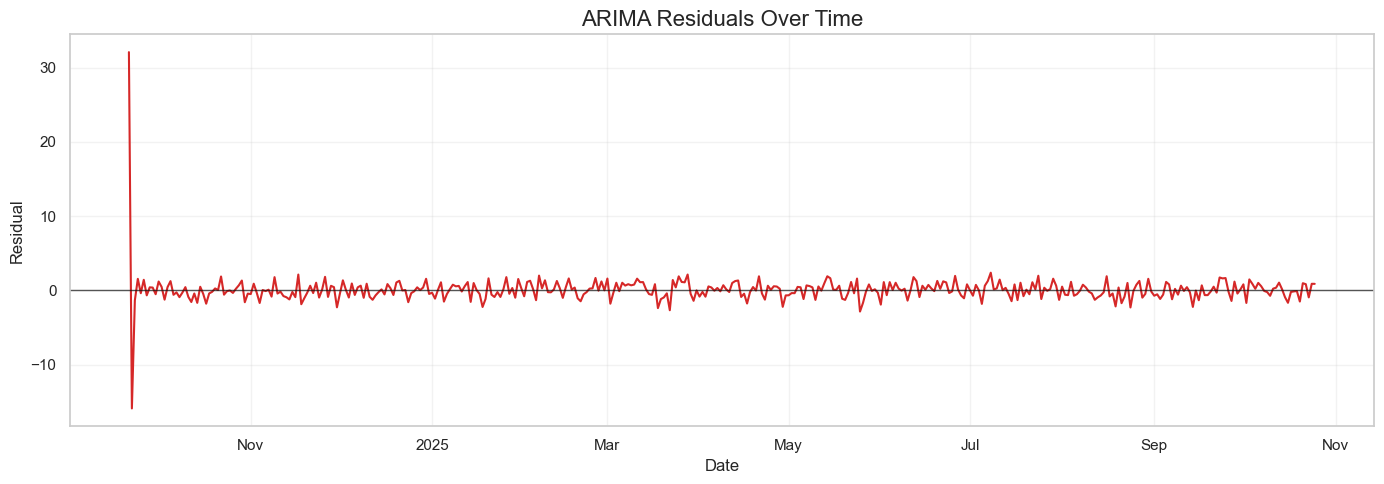

Residual mean: 0.068731
Residual std:  2.040604


In [80]:
# Plot 17 — Residuals Over Time
"""
Purpose:
Plot residuals against time to check whether they fluctuate randomly around zero.
Visible structure, shifts, or changing spread would suggest that the model has not captured all systematic behaviour.
"""

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(resid.index, resid, color=COL["red"], linewidth=1.5)
ax.axhline(0, color=COL["black"], linewidth=1.0, alpha=0.7)

ax.set_title("ARIMA Residuals Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")

prettify_time_axis(ax)
save_and_show(fig, "17_residuals_over_time", FIG_DIR)

print(f"Residual mean: {resid.mean():.6f}")
print(f"Residual std:  {resid.std():.6f}")

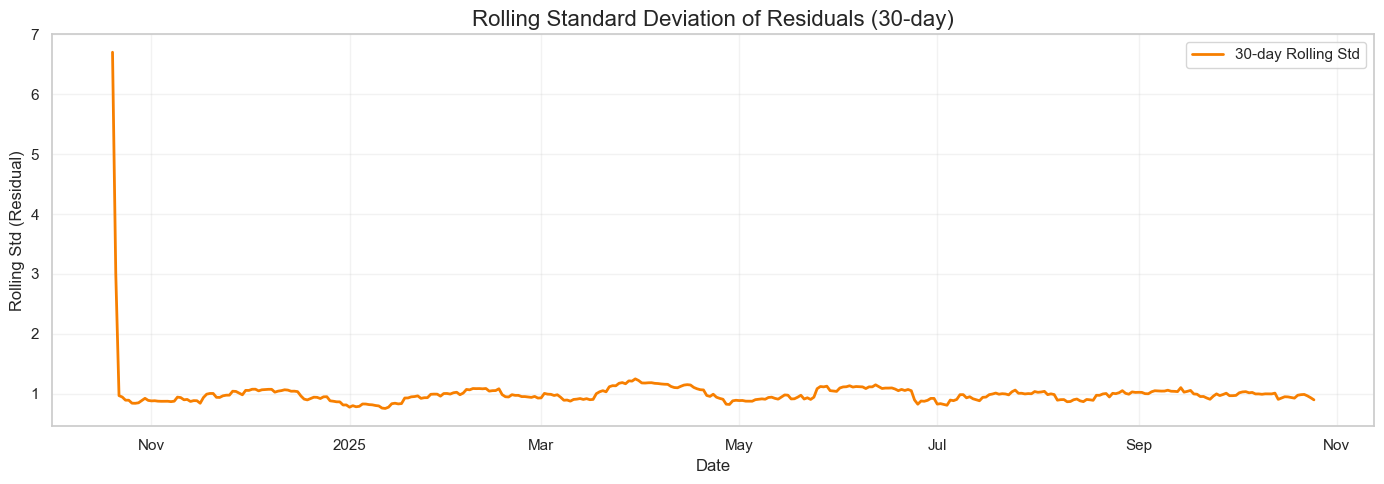

In [81]:
# Plot 18 — Rolling Standard Deviation of Residuals
"""
Purpose:
Examine whether the variance of the residuals remains stable through time.
Large variation in rolling residual volatility suggests heteroskedasticity not captured by the ARIMA model.
"""

res_window = 30
res_roll_std = resid.rolling(res_window).std()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    res_roll_std.index,
    res_roll_std,
    color=COL["orange"],
    linewidth=2.0,
    label=f"{res_window}-day Rolling Std"
)

ax.set_title(f"Rolling Standard Deviation of Residuals ({res_window}-day)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std (Residual)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "18_residual_rolling_std", FIG_DIR)

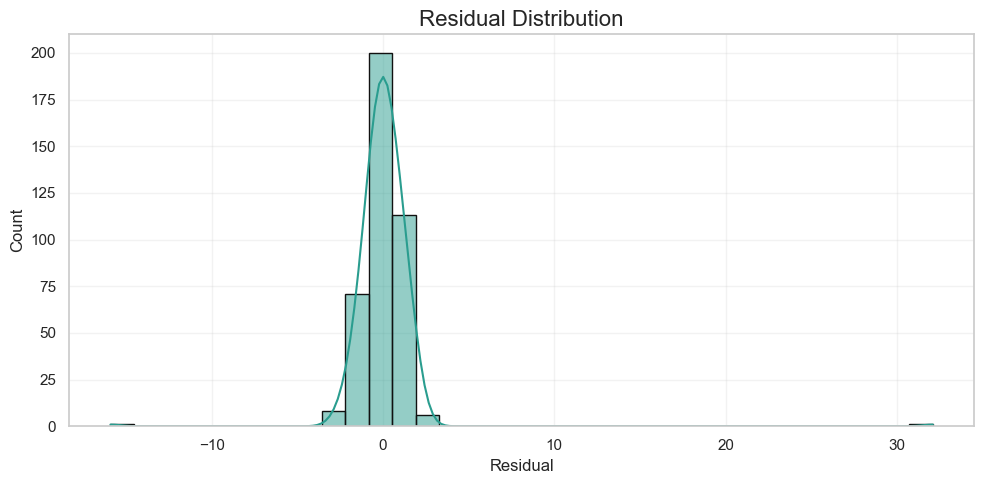

In [82]:
# Plot 19 — Residual Distribution
"""
Purpose:
Inspect the distribution of residuals to assess approximate normality and the presence of heavy tails.
This is useful for understanding the reliability of model-based confidence intervals.
"""

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    resid,
    bins=35,
    kde=True,
    color=COL["green"],
    edgecolor=COL["black"],
    ax=ax
)

ax.set_title("Residual Distribution")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")

save_and_show(fig, "19_residual_distribution", FIG_DIR)

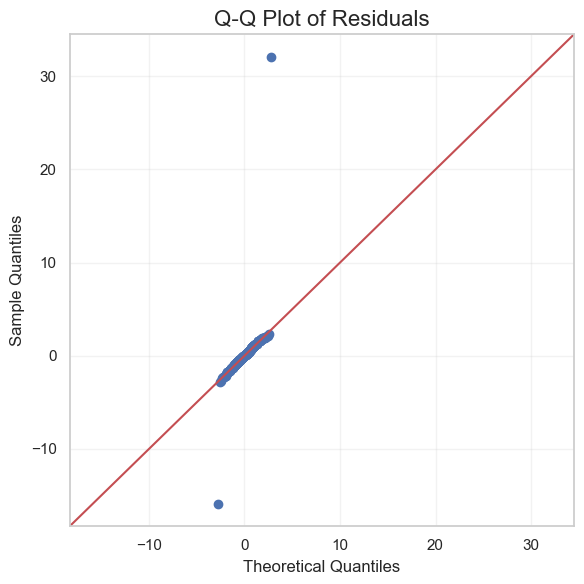

In [83]:
# Plot 20 — Q-Q Plot of Residuals
"""
Purpose:
Use a Q-Q plot to compare the residual distribution against a theoretical normal distribution.
Systematic deviations from the reference line indicate departures from normality.
"""

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

sm.qqplot(resid, line="45", ax=ax)
ax.set_title("Q-Q Plot of Residuals")

save_and_show(fig, "20_residual_qq_plot", FIG_DIR)

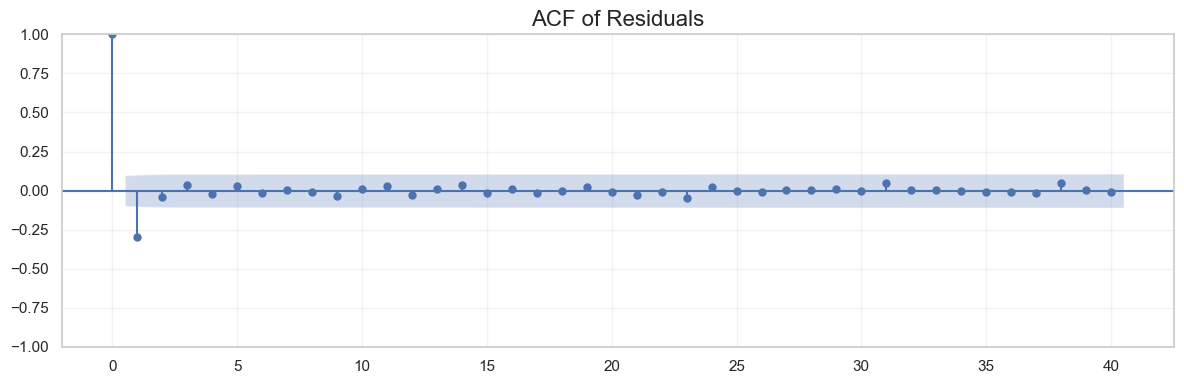

In [84]:
# Plot 21 — ACF of Residuals
"""
Purpose:
Check residual autocorrelation visually to confirm whether the model has adequately captured serial dependence.
Significant spikes in the residual ACF would indicate model underfitting.
"""

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(resid, lags=40, ax=ax)
ax.set_title("ACF of Residuals")

save_and_show(fig, "21_residual_acf", FIG_DIR)

In [85]:
# Step 16 — Refit Final ARIMA on Full Data and Forecast 24 Months Ahead
"""
Purpose:
Refit the strictly selected ARIMA model on all available data after unbiased evaluation
and produce the final forecast.

The assignment requires a 24-month forecast. Since the dataset is daily, this is
approximated as 730 calendar days.
"""

FORECAST_STEPS = 730

print("Forecast horizon explanation:")
print("24 months is approximated as 730 calendar days because the dataset is daily.")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_fit = fit_arima_once(series, SELECTED_ORDER, maxiter=ARIMA_FINAL_MAXITER)

forecast_res = final_fit.get_forecast(steps=FORECAST_STEPS)
fc_mean = forecast_res.predicted_mean
fc_ci = forecast_res.conf_int(alpha=0.05)

print(f"Final forecasting model: ARIMA{SELECTED_ORDER}")
print(f"Forecast horizon: {FORECAST_STEPS} daily steps")

Forecast horizon explanation:
24 months is approximated as 730 calendar days because the dataset is daily.
Final forecasting model: ARIMA(0, 2, 8)
Forecast horizon: 730 daily steps


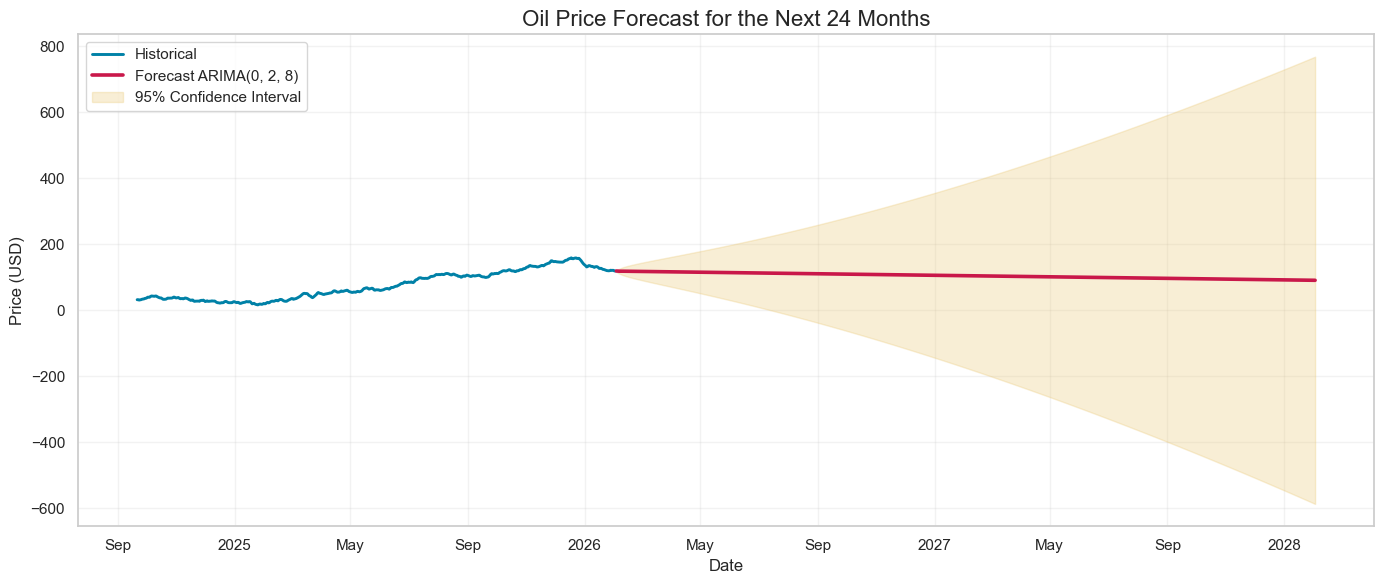

In [86]:
# Plot 22 — Final 24-Month Forecast with Confidence Intervals
"""
Purpose:
Plot the final forecast together with historical data and a 95% confidence interval band.
This is the main forecasting figure for Part 1 and should be included in the written report.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    series.index,
    series.values,
    color=COL["teal"],
    linewidth=2.1,
    label="Historical"
)

ax.plot(
    fc_mean.index,
    fc_mean.values,
    color=COL["rose"],
    linewidth=2.6,
    label=f"Forecast ARIMA{SELECTED_ORDER}"
)

ax.fill_between(
    fc_ci.index,
    fc_ci.iloc[:, 0].values,
    fc_ci.iloc[:, 1].values,
    color=COL["yellow"],
    alpha=0.28,
    label="95% Confidence Interval"
)

ax.set_title("Oil Price Forecast for the Next 24 Months")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "22_final_24_month_forecast", FIG_DIR)

In [87]:
# Step 17 — Rolling-Origin Validation (Robust Walk-Forward Check)
"""
Purpose:
Evaluate model robustness across several forecast windows using rolling-origin validation.
This provides stronger evidence than a single train/test split and supports high-level critical discussion.
"""

def rolling_origin_validation(series, order, initial_train_size, step=30, horizon=30, max_folds=6):
    """
    Perform walk-forward validation with robust failure handling.

    Parameters
    ----------
    series : pd.Series
        Full time series.
    order : tuple
        ARIMA order.
    initial_train_size : int
        Initial number of observations used for the first training fold.
    step : int
        Number of observations by which the training window expands each fold.
    horizon : int
        Forecast horizon for each fold.
    max_folds : int
        Maximum number of validation folds.

    Returns
    -------
    avg_rmse : float
        Mean RMSE across successful folds.
    fold_df : pd.DataFrame
        Fold-level evaluation results.
    """
    series = pd.Series(series).dropna()
    n = len(series)

    fold_rows = []
    fold = 0
    train_end = int(initial_train_size)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        while (train_end + horizon) <= n and fold < max_folds:
            train_fold = series.iloc[:train_end]
            test_fold = series.iloc[train_end:train_end + horizon]

            try:
                fit = fit_arima_once(train_fold, order, maxiter=ARIMA_FINAL_MAXITER)

                pred = fit.forecast(steps=horizon)
                pred = pd.Series(pred, index=test_fold.index)

                rmse, mae = compute_metrics(test_fold, pred)

                fold_rows.append({
                    "fold": fold + 1,
                    "train_end": train_fold.index[-1],
                    "test_start": test_fold.index[0],
                    "test_end": test_fold.index[-1],
                    "rmse": float(rmse),
                    "mae": float(mae),
                    "status": "ok"
                })

            except Exception as e:
                fold_rows.append({
                    "fold": fold + 1,
                    "train_end": train_fold.index[-1],
                    "test_start": test_fold.index[0],
                    "test_end": test_fold.index[-1],
                    "rmse": np.nan,
                    "mae": np.nan,
                    "status": f"failed: {str(e)[:80]}"
                })

            train_end += step
            fold += 1

    fold_df = pd.DataFrame(fold_rows)
    avg_rmse = float(np.nanmean(fold_df["rmse"])) if fold_df["rmse"].notna().any() else np.nan

    return avg_rmse, fold_df


initial_train_size = int(len(series) * 0.7)

avg_rmse_roll, fold_metrics = rolling_origin_validation(
    series=series,
    order=SELECTED_ORDER,
    initial_train_size=initial_train_size,
    step=30,
    horizon=30,
    max_folds=6
)

print(f"Rolling-origin model checked: ARIMA{SELECTED_ORDER}")
print(f"Average rolling-origin RMSE: {avg_rmse_roll:.4f}")
print(f"Successful folds: {(fold_metrics['status'] == 'ok').sum()} out of {len(fold_metrics)}")
display(fold_metrics)

Rolling-origin model checked: ARIMA(0, 2, 8)
Average rolling-origin RMSE: 6.1287
Successful folds: 5 out of 5


,fold,train_end,test_start,test_end,rmse,mae,status
0,1,2025-09-05,2025-09-06,2025-10-05,4.076830,2.747180,ok
1,2,2025-10-05,2025-10-06,2025-11-04,3.387895,2.645673,ok
2,3,2025-11-04,2025-11-05,2025-12-04,5.083979,4.347171,ok
3,4,2025-12-04,2025-12-05,2026-01-03,9.185323,6.141026,ok
4,5,2026-01-03,2026-01-04,2026-02-02,8.909666,7.420965,ok


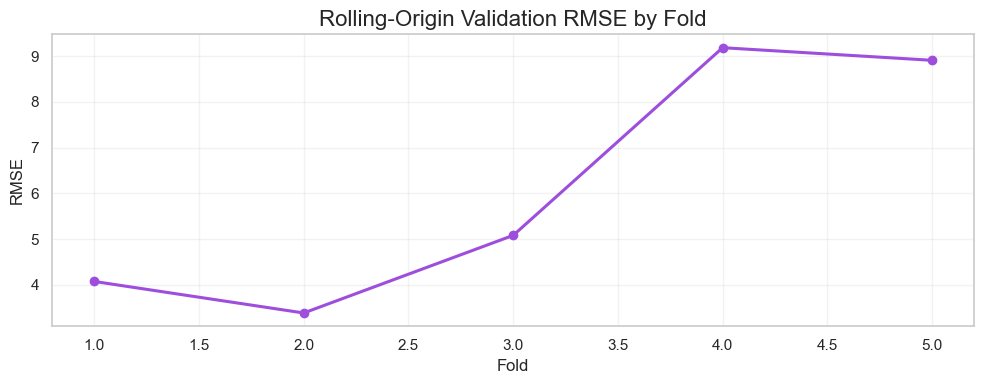

In [88]:
# Plot 23 — Rolling-Origin RMSE by Fold
"""
Purpose:
Plot RMSE across validation folds to assess whether forecast performance is stable over time.
Variation across folds may indicate sensitivity to regime changes or non-constant predictability.
"""

valid_folds = fold_metrics.dropna(subset=["rmse"]).copy()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    valid_folds["fold"],
    valid_folds["rmse"],
    marker="o",
    color=COL["purple"],
    linewidth=2.2
)

ax.set_title("Rolling-Origin Validation RMSE by Fold")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE")

save_and_show(fig, "23_rolling_origin_rmse", FIG_DIR)

In [90]:
# Step 18 — Final Notes for Report Writing
"""
Purpose:
Print a concise modelling summary that can guide the write-up of the report discussion
and conclusion sections. This helps connect the code outputs to the marking criteria
on interpretation, critique, and future improvements.
"""
# RMSE percentage for interpretation
rmse_pct = (rmse_arima / series.mean()) * 100

print("Report guidance summary:")
print(f"- Selected ARIMA model: {SELECTED_ORDER}")
print(f"- Test RMSE: {rmse_arima:.4f}")
print(f"- Test MAE: {mae_arima:.4f}")
print(f"- RMSE as % of mean price: {rmse_pct:.2f}%")
print(f"- 95% interval coverage on test set: {coverage_rate:.3%}")
print(f"- Residual white-noise check passed: {lb_ok}")
print(f"- ARCH p-value: {arch_pvalue:.6f}")

print("\nKey points to discuss in the report:")
print("- The original series is non-stationary, supported by visual evidence and formal stationarity tests.")
print("- First differencing improves stationarity and supports using ARIMA rather than ARMA on the raw series.")
print("- Model selection was done on training data only, which avoids leakage and strengthens evaluation credibility.")
print("- Baseline comparisons show whether ARIMA provides real predictive improvement.")
print("- Residual diagnostics indicate whether the model captures autocorrelation adequately and whether volatility remains an issue.")
print("- Forecast intervals widen over time, reflecting growing uncertainty in long-horizon prediction.")
print("- Possible future improvements include SARIMA, GARCH, ARIMAX, regime-switching, or deep learning models.")

Report guidance summary:
- Selected ARIMA model: (0, 2, 8)
- Test RMSE: 16.5060
- Test MAE: 13.5722
- RMSE as % of mean price: 21.75%
- 95% interval coverage on test set: 100.000%
- Residual white-noise check passed: False
- ARCH p-value: 0.994658

Key points to discuss in the report:
- The original series is non-stationary, supported by visual evidence and formal stationarity tests.
- First differencing improves stationarity and supports using ARIMA rather than ARMA on the raw series.
- Model selection was done on training data only, which avoids leakage and strengthens evaluation credibility.
- Baseline comparisons show whether ARIMA provides real predictive improvement.
- Residual diagnostics indicate whether the model captures autocorrelation adequately and whether volatility remains an issue.
- Forecast intervals widen over time, reflecting growing uncertainty in long-horizon prediction.
- Possible future improvements include SARIMA, GARCH, ARIMAX, regime-switching, or deep learni

### Part 2 — Alternative Model: LSTM

> Purpose:
Implement an LSTM-based forecasting pipeline as the alternative modelling approach for Part 2.
This section follows a strict time-series workflow with:
- chronological splitting
- train-only scaling
- supervised sequence construction
- validation-based tuning
- out-of-sample evaluation
- long-horizon forecasting

In [91]:
# Step 19 — TensorFlow Import and Reproducibility Settings
"""
Purpose:
Import TensorFlow/Keras and set random seeds so the LSTM results are more reproducible.
This is the core library used to build and train the alternative deep learning model.
"""

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, optimizers
except Exception as e:
    raise ImportError(
        "TensorFlow is required for Part 2 (LSTM) but is not available in this environment. "
        "Install it first, for example with: pip install tensorflow"
    ) from e

from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__ if "sklearn" in globals() else "loaded")

TensorFlow version: 2.20.0
NumPy version: 2.3.4
Pandas version: 2.3.3
Scikit-learn version: loaded


In [92]:
# Step 20 — Prepare Data for LSTM (Train/Test Already Defined)
"""
Purpose:
Use the same chronological train/test split from Part 1 so ARIMA and LSTM are compared fairly.
The target remains the oil price series, but the LSTM requires supervised sequence inputs
rather than a raw time series.
"""

print(f"Train observations: {len(train)}")
print(f"Test observations:  {len(test)}")
print(f"Train start: {train.index.min()}   Train end: {train.index.max()}")
print(f"Test start:  {test.index.min()}    Test end:  {test.index.max()}")

Train observations: 400
Test observations:  100
Train start: 2024-09-21 00:00:00   Train end: 2025-10-25 00:00:00
Test start:  2025-10-26 00:00:00    Test end:  2026-02-02 00:00:00


In [93]:
# Step 21 — Scale the Data Using Train Only (No Leakage)
"""
Purpose:
LSTM models are sensitive to scale, so the series is standardised before training.
The scaler is fitted only on the training data to avoid leaking information from the test period.
"""

lstm_scaler = StandardScaler()

train_scaled = lstm_scaler.fit_transform(train.values.reshape(-1, 1)).astype(np.float32).flatten()
test_scaled = lstm_scaler.transform(test.values.reshape(-1, 1)).astype(np.float32).flatten()

print("Scaling complete.")
print(f"Train scaled mean (approx): {train_scaled.mean():.4f}")
print(f"Train scaled std (approx):  {train_scaled.std():.4f}")

Scaling complete.
Train scaled mean (approx): 0.0000
Train scaled std (approx):  1.0000


In [94]:
# Step 22 — Create Supervised Sequences for LSTM
"""
Purpose:
Transform the univariate time series into supervised learning samples using a rolling lookback window.
Each input sequence contains the previous LOOKBACK observations, and the target is the next value in the series.
"""

def make_lstm_sequences(values, lookback):
    """
    Convert a 1D array into LSTM-ready supervised samples.

    Parameters
    ----------
    values : array-like
        1D time-series values.
    lookback : int
        Number of previous observations used as input.

    Returns
    -------
    X : np.ndarray
        Shape (n_samples, lookback, 1)
    y : np.ndarray
        Shape (n_samples,)
    """
    values = np.asarray(values, dtype=np.float32).reshape(-1)

    if not isinstance(lookback, (int, np.integer)) or lookback <= 0:
        raise ValueError(f"lookback must be a positive integer. Got: {lookback}")

    if len(values) <= lookback:
        raise ValueError(
            f"Sequence length {len(values)} is too short for lookback={lookback}."
        )

    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback:i])
        y.append(values[i])

    X = np.asarray(X, dtype=np.float32).reshape(-1, lookback, 1)
    y = np.asarray(y, dtype=np.float32)

    return X, y


# Initial default lookback for the tuning stage
LOOKBACK = 30

X_train_full, y_train_full = make_lstm_sequences(train_scaled, LOOKBACK)

combined_scaled = np.concatenate([train_scaled, test_scaled])
X_all, y_all = make_lstm_sequences(combined_scaled, LOOKBACK)

combined_index = train.index.append(test.index)
target_index = combined_index[LOOKBACK:]

test_mask = target_index.isin(test.index)
X_test_lstm = X_all[test_mask]
y_test_lstm = y_all[test_mask]
y_test_lstm_index = target_index[test_mask]

print("Initial sequence preparation complete.")
print("X_train_full shape:", X_train_full.shape)
print("y_train_full shape:", y_train_full.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

Initial sequence preparation complete.
X_train_full shape: (370, 30, 1)
y_train_full shape: (370,)
X_test_lstm shape: (100, 30, 1)
y_test_lstm shape: (100,)


In [95]:
# Step 23 — Create Chronological Validation Split for LSTM Training
"""
Purpose:
Reserve the end portion of the training sequences as a validation set to monitor overfitting.
This maintains chronological order and avoids shuffling future information backwards into model training.
"""

VAL_FRAC = 0.15

required_objects = ["X_train_full", "y_train_full"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        f"Missing required objects for Step 23: {missing_objects}. "
        "Run the earlier sequence-creation cell first."
    )

if len(X_train_full) == 0:
    raise ValueError("X_train_full is empty. Check make_lstm_sequences().")

if len(y_train_full) != len(X_train_full):
    raise ValueError("X_train_full and y_train_full have inconsistent lengths.")

val_size = max(1, int(len(X_train_full) * VAL_FRAC))

# Prevent the validation split from consuming the whole sample
if val_size >= len(X_train_full):
    val_size = max(1, len(X_train_full) // 5)

if val_size >= len(X_train_full):
    raise ValueError("Validation size is too large for the available training sequences.")

X_train_lstm = X_train_full[:-val_size]
y_train_lstm = y_train_full[:-val_size]

X_val_lstm = X_train_full[-val_size:]
y_val_lstm = y_train_full[-val_size:]

print("Training sequences:", X_train_lstm.shape[0])
print("Validation sequences:", X_val_lstm.shape[0])
print("Lookback used in current sequence set:", X_train_full.shape[1])
print("Validation fraction:", VAL_FRAC)



Training sequences: 315
Validation sequences: 55
Lookback used in current sequence set: 30
Validation fraction: 0.15


In [96]:
# Step 23A — LSTM Model Architecture
"""
Purpose:
Define the LSTM model architecture used for the alternative forecasting solution.
This function is used both for hyperparameter tuning and final model training.
"""

def build_lstm_model(lookback, lstm_units=64, dropout_rate=0.25, learning_rate=1e-3):
    """
    Build and compile an LSTM regression model for one-step forecasting.
    """

    if not isinstance(lookback, (int, np.integer)) or lookback <= 0:
        raise ValueError(f"lookback must be a positive integer. Got: {lookback}")

    if not isinstance(lstm_units, (int, np.integer)) or lstm_units <= 0:
        raise ValueError(f"lstm_units must be a positive integer. Got: {lstm_units}")

    if not (0 <= dropout_rate < 1):
        raise ValueError(f"dropout_rate must be in [0,1). Got: {dropout_rate}")

    if learning_rate <= 0:
        raise ValueError(f"learning_rate must be positive. Got: {learning_rate}")

    model = models.Sequential([
        layers.Input(shape=(int(lookback), 1)),
        layers.LSTM(int(lstm_units), return_sequences=False),
        layers.Dropout(float(dropout_rate)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(float(dropout_rate)),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=float(learning_rate)),
        loss="mse"
    )

    return model

In [97]:
# Step 24 — Systematic LSTM Hyperparameter Tuning
"""
Purpose:
Tune key LSTM hyperparameters using a chronological validation set so the alternative model
is selected systematically rather than by arbitrary fixed settings.
"""

required_objects = [
    "train_scaled", "VAL_FRAC", "make_lstm_sequences",
    "build_lstm_model", "callbacks"
]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        f"Missing required objects for Step 24: {missing_objects}. "
        "Run the earlier preprocessing and architecture cells first."
    )

train_scaled = np.asarray(train_scaled, dtype=np.float32).reshape(-1)

def evaluate_lstm_config(lookback, lstm_units, dropout_rate, learning_rate, batch_size):
    """
    Train one LSTM configuration and return validation performance.
    The validation set remains chronological to preserve time-series integrity.
    """
    X_train_full_cfg, y_train_full_cfg = make_lstm_sequences(train_scaled, int(lookback))

    if len(X_train_full_cfg) == 0:
        raise ValueError(f"No sequences created for lookback={lookback}.")

    val_size_cfg = max(1, int(len(X_train_full_cfg) * VAL_FRAC))

    if val_size_cfg >= len(X_train_full_cfg):
        val_size_cfg = max(1, len(X_train_full_cfg) // 5)

    if val_size_cfg >= len(X_train_full_cfg):
        raise ValueError(
            f"Validation split too large for lookback={lookback}. "
            f"Number of sequences = {len(X_train_full_cfg)}"
        )

    X_train_cfg = X_train_full_cfg[:-val_size_cfg]
    y_train_cfg = y_train_full_cfg[:-val_size_cfg]
    X_val_cfg = X_train_full_cfg[-val_size_cfg:]
    y_val_cfg = y_train_full_cfg[-val_size_cfg:]

    model = build_lstm_model(
        lookback=int(lookback),
        lstm_units=int(lstm_units),
        dropout_rate=float(dropout_rate),
        learning_rate=float(learning_rate)
    )

    early_stop_cfg = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_cfg,
        y_train_cfg,
        validation_data=(X_val_cfg, y_val_cfg),
        epochs=200,
        batch_size=int(batch_size),
        verbose=0,
        shuffle=False,
        callbacks=[early_stop_cfg]
    )

    best_val_loss = float(np.min(history.history["val_loss"]))

    return {
        "model": model,
        "history": history,
        "lookback": int(lookback),
        "lstm_units": int(lstm_units),
        "dropout_rate": float(dropout_rate),
        "learning_rate": float(learning_rate),
        "batch_size": int(batch_size),
        "best_val_loss": best_val_loss
    }


# Practical tuning grid
lstm_configs = [
    {"lookback": 15, "lstm_units": 32,  "dropout_rate": 0.15, "learning_rate": 1e-3, "batch_size": 16},
    {"lookback": 30, "lstm_units": 32,  "dropout_rate": 0.20, "learning_rate": 1e-3, "batch_size": 16},
    {"lookback": 30, "lstm_units": 64,  "dropout_rate": 0.25, "learning_rate": 1e-3, "batch_size": 32},
    {"lookback": 60, "lstm_units": 64,  "dropout_rate": 0.25, "learning_rate": 1e-3, "batch_size": 32},
    {"lookback": 60, "lstm_units": 128, "dropout_rate": 0.30, "learning_rate": 5e-4, "batch_size": 32},
]

tuning_results = []
tuning_failures = []

for cfg in lstm_configs:
    try:
        result = evaluate_lstm_config(**cfg)
        tuning_results.append(result)
    except Exception as e:
        tuning_failures.append({
            "lookback": cfg["lookback"],
            "lstm_units": cfg["lstm_units"],
            "dropout_rate": cfg["dropout_rate"],
            "learning_rate": cfg["learning_rate"],
            "batch_size": cfg["batch_size"],
            "error": str(e)
        })

if len(tuning_results) == 0:
    raise RuntimeError(
        "All LSTM tuning configurations failed. "
        "Inspect tuning_failures for details."
    )

tuning_table = pd.DataFrame([
    {
        "lookback": r["lookback"],
        "lstm_units": r["lstm_units"],
        "dropout_rate": r["dropout_rate"],
        "learning_rate": r["learning_rate"],
        "batch_size": r["batch_size"],
        "best_val_loss": r["best_val_loss"]
    }
    for r in tuning_results
]).sort_values("best_val_loss").reset_index(drop=True)

print("LSTM tuning results:")
display(tuning_table.round(6))

if len(tuning_failures) > 0:
    print("Some tuning configurations failed:")
    display(pd.DataFrame(tuning_failures))

best_lstm_result = min(tuning_results, key=lambda x: x["best_val_loss"])

BEST_LOOKBACK = best_lstm_result["lookback"]
BEST_LSTM_UNITS = best_lstm_result["lstm_units"]
BEST_DROPOUT = best_lstm_result["dropout_rate"]
BEST_LR = best_lstm_result["learning_rate"]
BEST_BATCH = best_lstm_result["batch_size"]

print("Best tuned LSTM configuration:")
print(f"BEST_LOOKBACK:   {BEST_LOOKBACK}")
print(f"BEST_LSTM_UNITS: {BEST_LSTM_UNITS}")
print(f"BEST_DROPOUT:    {BEST_DROPOUT}")
print(f"BEST_LR:         {BEST_LR}")
print(f"BEST_BATCH:      {BEST_BATCH}")

LSTM tuning results:


,lookback,lstm_units,dropout_rate,learning_rate,batch_size,best_val_loss
0,30,32,0.20,0.0010,16,0.010456
1,15,32,0.15,0.0010,16,0.010783
2,60,64,0.25,0.0010,32,0.014382
3,60,128,0.30,0.0005,32,0.015361
4,30,64,0.25,0.0010,32,0.021345


Best tuned LSTM configuration:
BEST_LOOKBACK:   30
BEST_LSTM_UNITS: 32
BEST_DROPOUT:    0.2
BEST_LR:         0.001
BEST_BATCH:      16


In [98]:
# Step 25 — Train the Final Tuned LSTM with Early Stopping
"""
Purpose:
Train the final LSTM model using the best hyperparameters selected during tuning.
This ensures the alternative model is chosen systematically and not by arbitrary fixed settings.
"""

required_objects = [
    "np", "pd",
    "train", "test",
    "train_scaled", "test_scaled",
    "VAL_FRAC",
    "make_lstm_sequences",
    "build_lstm_model",
    "callbacks",
    "BEST_LOOKBACK", "BEST_LSTM_UNITS", "BEST_DROPOUT", "BEST_LR", "BEST_BATCH"
]

missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "The following required objects are missing:\n"
        f"{missing_objects}\n\n"
        "Run the earlier preprocessing, architecture, and tuning cells first."
    )

train_scaled = np.asarray(train_scaled, dtype=np.float32).reshape(-1)
test_scaled = np.asarray(test_scaled, dtype=np.float32).reshape(-1)

# Rebuild sequences using tuned lookback
X_train_full, y_train_full = make_lstm_sequences(train_scaled, int(BEST_LOOKBACK))

if len(X_train_full) == 0:
    raise ValueError(
        "No training sequences were created. Check make_lstm_sequences() and BEST_LOOKBACK."
    )

val_size = max(1, int(len(X_train_full) * VAL_FRAC))

if val_size >= len(X_train_full):
    val_size = max(1, len(X_train_full) // 5)

if val_size >= len(X_train_full):
    raise ValueError("Validation split is too large relative to the available training sequences.")

X_train_lstm = X_train_full[:-val_size]
y_train_lstm = y_train_full[:-val_size]
X_val_lstm = X_train_full[-val_size:]
y_val_lstm = y_train_full[-val_size:]

if len(X_train_lstm) == 0 or len(X_val_lstm) == 0:
    raise ValueError(
        "Training or validation set became empty after splitting. "
        "Reduce BEST_LOOKBACK or adjust VAL_FRAC."
    )

# Final tuned model
lstm_model = build_lstm_model(
    lookback=int(BEST_LOOKBACK),
    lstm_units=int(BEST_LSTM_UNITS),
    dropout_rate=float(BEST_DROPOUT),
    learning_rate=float(BEST_LR)
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=300,
    batch_size=int(BEST_BATCH),
    verbose=0,
    shuffle=False,
    callbacks=[early_stop]
)

print("Final tuned LSTM training complete.")
print(f"Best validation loss: {min(lstm_history.history['val_loss']):.6f}")
print(f"Epochs run: {len(lstm_history.history['loss'])}")
print(f"Training samples: {len(X_train_lstm)}")
print(f"Validation samples: {len(X_val_lstm)}")
print(f"Lookback used: {BEST_LOOKBACK}")

lstm_model.summary()

Final tuned LSTM training complete.
Best validation loss: 0.025434
Epochs run: 18
Training samples: 315
Validation samples: 55
Lookback used: 30


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,733 (100.52 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,156 (67.02 KB)

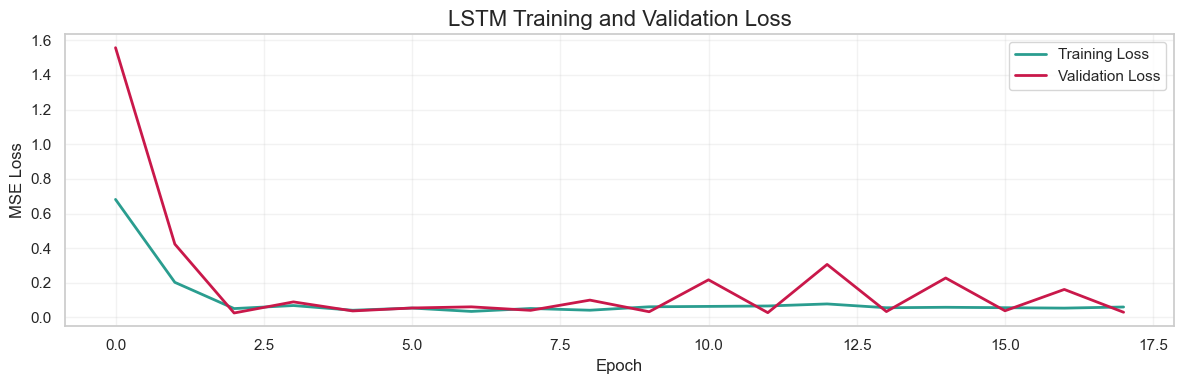

In [99]:
# Plot 24 — LSTM Training and Validation Loss
"""
Purpose:
Visualise training and validation loss to assess convergence and detect overfitting behaviour.
A stable validation curve supports the reliability of the trained LSTM model.
"""

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    lstm_history.history["loss"],
    color=COL["green"],
    linewidth=2.0,
    label="Training Loss"
)
ax.plot(
    lstm_history.history["val_loss"],
    color=COL["rose"],
    linewidth=2.0,
    label="Validation Loss"
)

ax.set_title("LSTM Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

save_and_show(fig, "24_lstm_training_validation_loss", FIG_DIR)

In [100]:
# Step 26 — Generate Fair Recursive Multi-Step LSTM Predictions on the Test Set
"""
Purpose:
Evaluate the tuned LSTM fairly on the full test horizon using recursive multi-step forecasting,
so the holdout evaluation is directly comparable to ARIMA.

For transparency, this cell also computes one-step-ahead predictions as a diagnostic only,
but the MAIN reported LSTM test metrics are based on the recursive forecast.
"""

# -----------------------------
# A) Diagnostic only: one-step-ahead test predictions
# -----------------------------
combined_scaled = np.concatenate([train_scaled, test_scaled]).astype(np.float32)
X_all, y_all = make_lstm_sequences(combined_scaled, int(BEST_LOOKBACK))

combined_index = train.index.append(test.index)
target_index = combined_index[int(BEST_LOOKBACK):]

test_mask = target_index.isin(test.index)
X_test_lstm = X_all[test_mask]
y_test_lstm = y_all[test_mask]
y_test_lstm_index = target_index[test_mask]

y_pred_lstm_1step_scaled = lstm_model.predict(X_test_lstm, verbose=0).flatten()

y_pred_lstm_1step = lstm_scaler.inverse_transform(
    y_pred_lstm_1step_scaled.reshape(-1, 1)
).flatten()

y_true_lstm_1step = lstm_scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).flatten()

lstm_pred_series_1step = pd.Series(y_pred_lstm_1step, index=y_test_lstm_index)
lstm_true_series_1step = pd.Series(y_true_lstm_1step, index=y_test_lstm_index)

rmse_lstm_1step, mae_lstm_1step = compute_metrics(lstm_true_series_1step, lstm_pred_series_1step)

# -----------------------------
# B) MAIN evaluation: recursive multi-step forecast over the full test horizon
# -----------------------------
lookback = int(BEST_LOOKBACK)

if len(train_scaled) < lookback:
    raise ValueError(
        f"Training series length ({len(train_scaled)}) is smaller than BEST_LOOKBACK ({lookback})."
    )

current_window = (
    train_scaled[-lookback:]
    .reshape(1, lookback, 1)
    .astype(np.float32)
)

recursive_scaled_preds = []

for _ in range(len(test)):
    next_scaled = float(lstm_model.predict(current_window, verbose=0).flatten()[0])
    recursive_scaled_preds.append(next_scaled)

    current_window = np.roll(current_window, shift=-1, axis=1)
    current_window[0, -1, 0] = next_scaled

recursive_scaled_preds = np.asarray(recursive_scaled_preds, dtype=np.float32)

y_pred_lstm = lstm_scaler.inverse_transform(
    recursive_scaled_preds.reshape(-1, 1)
).flatten()

y_true_lstm = test.values.astype(float)

lstm_pred_series = pd.Series(y_pred_lstm, index=test.index, name="lstm_recursive_forecast")
lstm_true_series = pd.Series(y_true_lstm, index=test.index, name="actual_test")

rmse_lstm, mae_lstm = compute_metrics(lstm_true_series, lstm_pred_series)
rmse_lstm_pct = 100 * rmse_lstm / series.mean()

# -----------------------------
# Reporting
# -----------------------------
print("LSTM Test Performance")
print("- Main evaluation = recursive multi-step forecast across the full test horizon")
print("- Diagnostic only = one-step-ahead predictions using rolling observed lags")

print(f"\nRecursive LSTM RMSE: {rmse_lstm:.4f}")
print(f"Recursive LSTM MAE:  {mae_lstm:.4f}")
print(f"Recursive LSTM RMSE as % of average price: {rmse_lstm_pct:.2f}%")

print("\nDiagnostic one-step-ahead results:")
print(f"One-step LSTM RMSE:  {rmse_lstm_1step:.4f}")
print(f"One-step LSTM MAE:   {mae_lstm_1step:.4f}")

print(f"\nRecursive forecast points: {len(lstm_pred_series)}")
print(f"Test-set points:           {len(test)}")
print(f"Forecast index matches test index: {lstm_pred_series.index.equals(test.index)}")

LSTM Test Performance
- Main evaluation = recursive multi-step forecast across the full test horizon
- Diagnostic only = one-step-ahead predictions using rolling observed lags

Recursive LSTM RMSE: 29.5574
Recursive LSTM MAE:  27.0366
Recursive LSTM RMSE as % of average price: 38.96%

Diagnostic one-step-ahead results:
One-step LSTM RMSE:  21.3474
One-step LSTM MAE:   19.0802

Recursive forecast points: 100
Test-set points:           100
Forecast index matches test index: True


In [101]:
# Step 26A — Baseline Forecast Metrics
"""
Purpose:
Compute evaluation metrics for the baseline forecasting methods
so they can be compared fairly against ARIMA and LSTM.
"""

rmse_naive, mae_naive = compute_metrics(test, naive_fc)
rmse_mean, mae_mean = compute_metrics(test, mean_fc)
rmse_drift, mae_drift = compute_metrics(test, drift_fc)

print("Baseline test metrics:")
print(f"Naive Forecast        -> RMSE: {rmse_naive:.4f}, MAE: {mae_naive:.4f}")
print(f"Mean Forecast         -> RMSE: {rmse_mean:.4f}, MAE: {mae_mean:.4f}")
print(f"Random Walk + Drift   -> RMSE: {rmse_drift:.4f}, MAE: {mae_drift:.4f}")

Baseline test metrics:
Naive Forecast        -> RMSE: 19.3001, MAE: 15.7668
Mean Forecast         -> RMSE: 77.9278, MAE: 77.0493
Random Walk + Drift   -> RMSE: 15.0182, MAE: 13.2190


In [102]:
# Step 27 — Compare LSTM Against ARIMA and Baselines
"""
Purpose:
Print a direct metric comparison so the relative strengths of the alternative model are clear.
This supports the report section where both methods must be compared critically using the same evaluation basis.
"""

comparison_df = pd.DataFrame({
    "Model": [
        f"ARIMA{SELECTED_ORDER}",
        "LSTM",
        "Naive",
        "Mean",
        "Random Walk + Drift"
    ],
    "RMSE": [
        rmse_arima,
        rmse_lstm,
        rmse_naive,
        rmse_mean,
        rmse_drift
    ],
    "MAE": [
        mae_arima,
        mae_lstm,
        mae_naive,
        mae_mean,
        mae_drift
    ]
}).sort_values("RMSE").reset_index(drop=True)

print("Model comparison table:")
display(comparison_df.round(4))

Model comparison table:


,Model,RMSE,MAE
0,Random Walk + Drift,15.0182,13.2190
1,"ARIMA(0, 2, 8)",16.5060,13.5722
2,Naive,19.3001,15.7668
3,LSTM,29.5574,27.0366
4,Mean,77.9278,77.0493


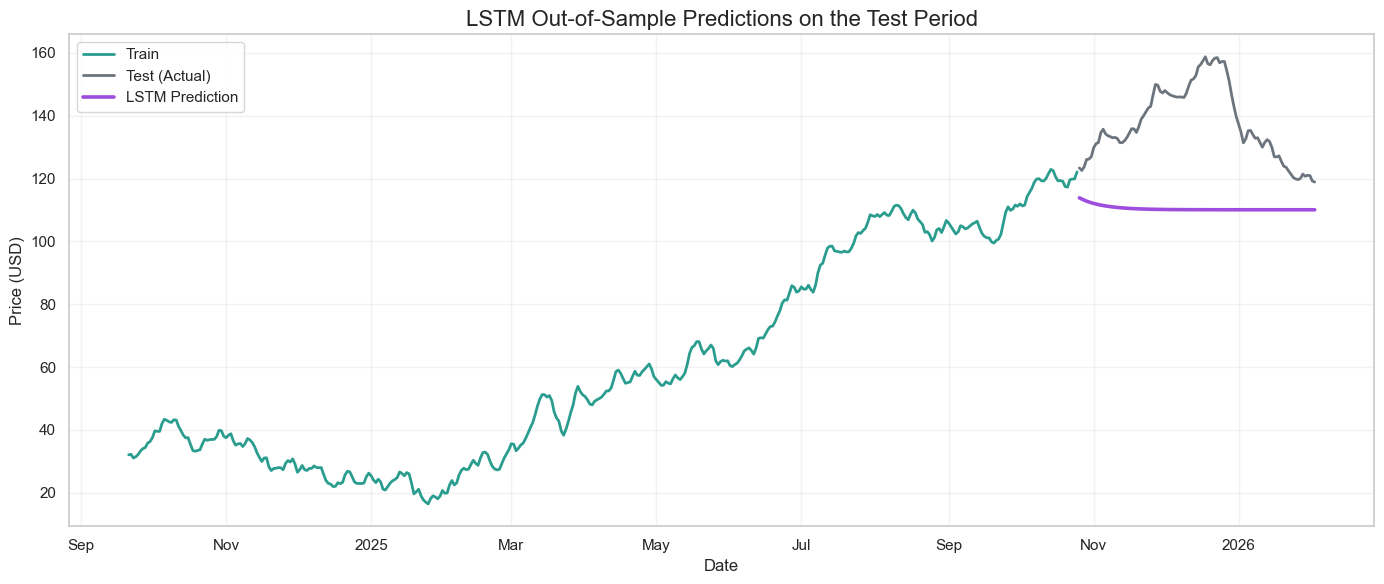

In [103]:
# Plot 25 — LSTM Predictions on the Test Set
"""
Purpose:
Visualise how the LSTM tracks the actual test-period oil prices.
This helps identify whether the model follows turning points, smooths too much,
or reacts too slowly to rapid changes.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color=COL["green"], linewidth=2.0, label="Train")
ax.plot(test.index, test, color=COL["grey"], linewidth=2.0, label="Test (Actual)")
ax.plot(
    lstm_pred_series.index,
    lstm_pred_series.values,
    color=COL["purple"],
    linewidth=2.6,
    label="LSTM Prediction"
)

ax.set_title("LSTM Out-of-Sample Predictions on the Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "25_lstm_test_predictions", FIG_DIR)

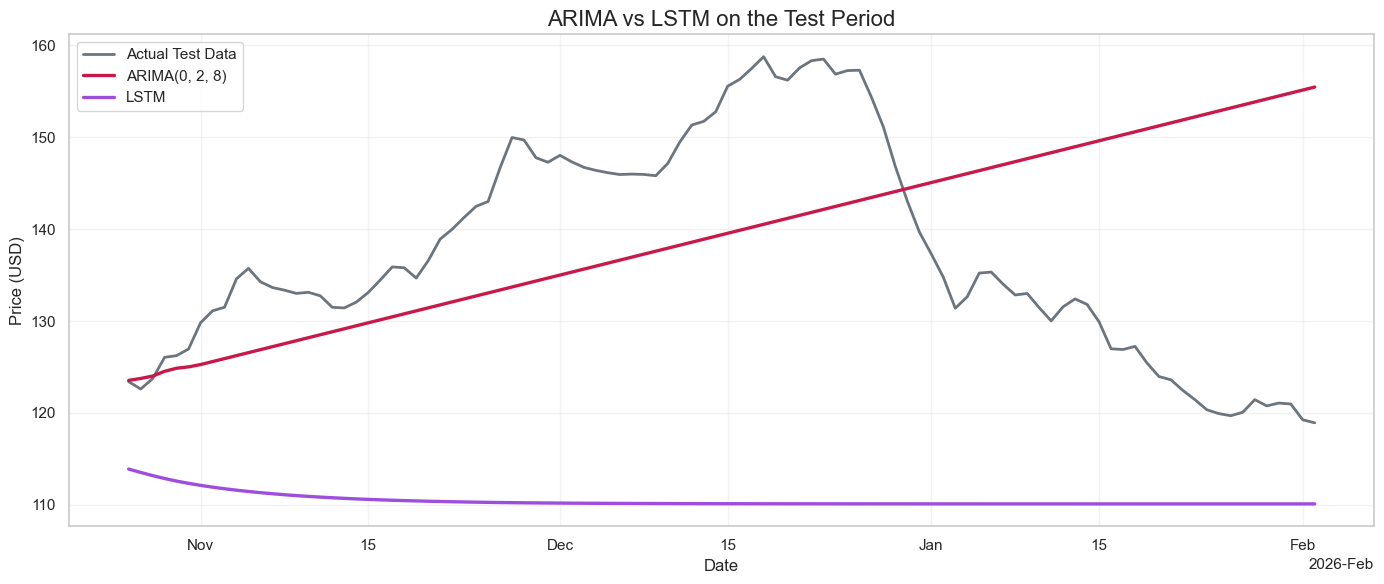

In [104]:
# Plot 26 — ARIMA vs LSTM on the Test Set
"""
Purpose:
Directly compare the two main modelling approaches against the same observed test data.
This figure is highly useful in the report because it makes comparative strengths
and weaknesses visually clear.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test.index, test.values, color=COL["grey"], linewidth=2.0, label="Actual Test Data")
ax.plot(
    arima_test_mean.index,
    arima_test_mean.values,
    color=COL["rose"],
    linewidth=2.4,
    label=f"ARIMA{SELECTED_ORDER}"
)
ax.plot(
    lstm_pred_series.index,
    lstm_pred_series.values,
    color=COL["purple"],
    linewidth=2.4,
    label="LSTM"
)

ax.set_title("ARIMA vs LSTM on the Test Period")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "26_arima_vs_lstm_test", FIG_DIR)

In [105]:
# Step 28 — Refit the Best Tuned LSTM on All Available Data
"""
Purpose:
Refit the tuned LSTM on the full available series so the final forecast uses all information.
A chronological validation split is kept explicitly for early stopping.
"""

full_series = series.copy()

full_scaler = StandardScaler()
full_scaled = full_scaler.fit_transform(full_series.values.reshape(-1, 1)).astype(np.float32).flatten()

X_full_lstm, y_full_lstm = make_lstm_sequences(full_scaled, int(BEST_LOOKBACK))

if len(X_full_lstm) == 0:
    raise ValueError("No full-series sequences were created for the final LSTM refit.")

full_val_size = max(1, int(len(X_full_lstm) * 0.15))
if full_val_size >= len(X_full_lstm):
    full_val_size = max(1, len(X_full_lstm) // 5)

if full_val_size >= len(X_full_lstm):
    raise ValueError("Validation split is too large for the full-series LSTM refit.")

X_full_train = X_full_lstm[:-full_val_size]
y_full_train = y_full_lstm[:-full_val_size]
X_full_val = X_full_lstm[-full_val_size:]
y_full_val = y_full_lstm[-full_val_size:]

full_lstm_model = build_lstm_model(
    lookback=int(BEST_LOOKBACK),
    lstm_units=int(BEST_LSTM_UNITS),
    dropout_rate=float(BEST_DROPOUT),
    learning_rate=float(BEST_LR)
)

early_stop_full = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

full_lstm_history = full_lstm_model.fit(
    X_full_train,
    y_full_train,
    validation_data=(X_full_val, y_full_val),
    epochs=300,
    batch_size=int(BEST_BATCH),
    verbose=0,
    shuffle=False,
    callbacks=[early_stop_full]
)

print("Full-data tuned LSTM refit complete.")
print(f"Best validation loss: {min(full_lstm_history.history['val_loss']):.6f}")
print(f"Epochs run: {len(full_lstm_history.history['loss'])}")

Full-data tuned LSTM refit complete.
Best validation loss: 0.004081
Epochs run: 124


In [106]:
# Step 29 — Recursive 24-Month LSTM Forecast
"""
Purpose:
Generate a 24-month forecast recursively by feeding each new prediction back into the next input window.
This produces the long-horizon forecast required for Part 2.
"""

FORECAST_STEPS_LSTM = 730

last_window = full_scaled[-int(BEST_LOOKBACK):].reshape(1, int(BEST_LOOKBACK), 1).astype(np.float32)
future_scaled = []

current_window = last_window.copy()

for _ in range(FORECAST_STEPS_LSTM):
    next_scaled = full_lstm_model.predict(current_window, verbose=0).flatten()[0]
    future_scaled.append(next_scaled)

    current_window = np.roll(current_window, shift=-1, axis=1)
    current_window[0, -1, 0] = next_scaled

future_scaled = np.asarray(future_scaled, dtype=np.float32)
future_pred = full_scaler.inverse_transform(future_scaled.reshape(-1, 1)).flatten()

future_index = pd.date_range(
    start=full_series.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_STEPS_LSTM,
    freq="D"
)

lstm_forecast_series = pd.Series(future_pred, index=future_index)

print("Tuned LSTM 24-month recursive forecast generated.")
print(f"Forecast horizon: {FORECAST_STEPS_LSTM} daily steps")

Tuned LSTM 24-month recursive forecast generated.
Forecast horizon: 730 daily steps


In [107]:
# Step 30 — Fast Monte Carlo Dropout for LSTM Prediction Intervals
"""
Purpose:
Approximate forecast uncertainty for the LSTM using Monte Carlo dropout.
These are approximate prediction intervals, not classical statistical confidence intervals,
so they should be interpreted more cautiously than the ARIMA intervals.

This version is much faster because it batches all simulation paths together at each forecast step
instead of calling the model separately for every simulation.
"""

def mc_dropout_forecast_fast(model, start_window, steps, n_sims=100):
    """
    Generate stochastic recursive forecast paths using dropout at inference time.

    Parameters
    ----------
    model : keras model
        Trained LSTM model.
    start_window : np.ndarray
        Shape (1, lookback, 1), last observed scaled window.
    steps : int
        Forecast horizon.
    n_sims : int
        Number of Monte Carlo simulation paths.

    Returns
    -------
    sims : np.ndarray
        Shape (n_sims, steps), simulated future scaled values.
    """
    if start_window.ndim != 3 or start_window.shape[0] != 1:
        raise ValueError(
            f"start_window must have shape (1, lookback, 1). Got {start_window.shape}"
        )

    window_batch = np.repeat(start_window, repeats=int(n_sims), axis=0).astype(np.float32)
    sims = np.zeros((int(n_sims), int(steps)), dtype=np.float32)

    for t in range(int(steps)):
        next_scaled = model(window_batch, training=True).numpy().reshape(-1)
        sims[:, t] = next_scaled

        window_batch = np.roll(window_batch, shift=-1, axis=1)
        window_batch[:, -1, 0] = next_scaled

    return sims


# 100 simulations is a strong balance between runtime and interval quality
N_SIMS = 100

mc_sims_scaled = mc_dropout_forecast_fast(
    full_lstm_model,
    start_window=last_window,
    steps=FORECAST_STEPS_LSTM,
    n_sims=N_SIMS
)

mc_sims = full_scaler.inverse_transform(
    mc_sims_scaled.reshape(-1, 1)
).reshape(N_SIMS, FORECAST_STEPS_LSTM)

lstm_lower_95 = np.percentile(mc_sims, 2.5, axis=0)
lstm_upper_95 = np.percentile(mc_sims, 97.5, axis=0)
lstm_mean_mc = np.mean(mc_sims, axis=0)

lstm_fc_mean = pd.Series(lstm_mean_mc, index=future_index)
lstm_fc_lower = pd.Series(lstm_lower_95, index=future_index)
lstm_fc_upper = pd.Series(lstm_upper_95, index=future_index)

print("Fast Monte Carlo dropout intervals computed for the tuned LSTM.")
print(f"Number of simulation paths: {N_SIMS}")
print("Interpretation note: these are approximate predictive intervals, not exact confidence intervals.")

Fast Monte Carlo dropout intervals computed for the tuned LSTM.
Number of simulation paths: 100
Interpretation note: these are approximate predictive intervals, not exact confidence intervals.


In [108]:
# Step 30A — Recursive LSTM Prediction Interval Coverage on the Test Set
"""
Purpose:
Evaluate approximate LSTM interval coverage on the test set using a RECURSIVE forecast setup,
so the uncertainty evaluation is aligned with the main multi-step LSTM test forecast.
"""

def mc_dropout_recursive_paths(model, start_window, steps, n_sims=100):
    """
    Generate recursive Monte Carlo dropout forecast paths from a single start window.

    Parameters
    ----------
    model : keras model
        Trained LSTM model.
    start_window : np.ndarray
        Shape (1, lookback, 1), last observed scaled window.
    steps : int
        Forecast horizon.
    n_sims : int
        Number of simulation paths.

    Returns
    -------
    sims : np.ndarray
        Shape (n_sims, steps), simulated future scaled values.
    """
    if start_window.ndim != 3 or start_window.shape[0] != 1:
        raise ValueError(
            f"start_window must have shape (1, lookback, 1). Got {start_window.shape}"
        )

    window_batch = np.repeat(start_window.astype(np.float32), repeats=int(n_sims), axis=0)
    sims = np.zeros((int(n_sims), int(steps)), dtype=np.float32)

    for t in range(int(steps)):
        next_scaled = model(window_batch, training=True).numpy().reshape(-1)
        sims[:, t] = next_scaled

        window_batch = np.roll(window_batch, shift=-1, axis=1)
        window_batch[:, -1, 0] = next_scaled

    return sims


LSTM_TEST_N_SIMS = 100

test_start_window = train_scaled[-int(BEST_LOOKBACK):].reshape(1, int(BEST_LOOKBACK), 1).astype(np.float32)

lstm_test_sims_scaled = mc_dropout_recursive_paths(
    lstm_model,
    start_window=test_start_window,
    steps=len(test),
    n_sims=LSTM_TEST_N_SIMS
)

lstm_test_sims = lstm_scaler.inverse_transform(
    lstm_test_sims_scaled.reshape(-1, 1)
).reshape(LSTM_TEST_N_SIMS, len(test))

lstm_test_lower = np.percentile(lstm_test_sims, 2.5, axis=0)
lstm_test_upper = np.percentile(lstm_test_sims, 97.5, axis=0)
lstm_test_mean = np.mean(lstm_test_sims, axis=0)

actual_lstm_test = test.values.copy()
lstm_covered = (actual_lstm_test >= lstm_test_lower) & (actual_lstm_test <= lstm_test_upper)
lstm_coverage_rate = float(lstm_covered.mean())

print(f"Approximate 95% recursive LSTM interval coverage on test set: {lstm_coverage_rate:.3%}")

if lstm_coverage_rate < 0.90:
    print("LSTM prediction intervals appear too narrow on the test set.")
elif lstm_coverage_rate > 0.98:
    print("LSTM prediction intervals may be overly wide on the test set.")
else:
    print("LSTM prediction interval coverage appears reasonably calibrated.")

Approximate 95% recursive LSTM interval coverage on test set: 23.000%
LSTM prediction intervals appear too narrow on the test set.


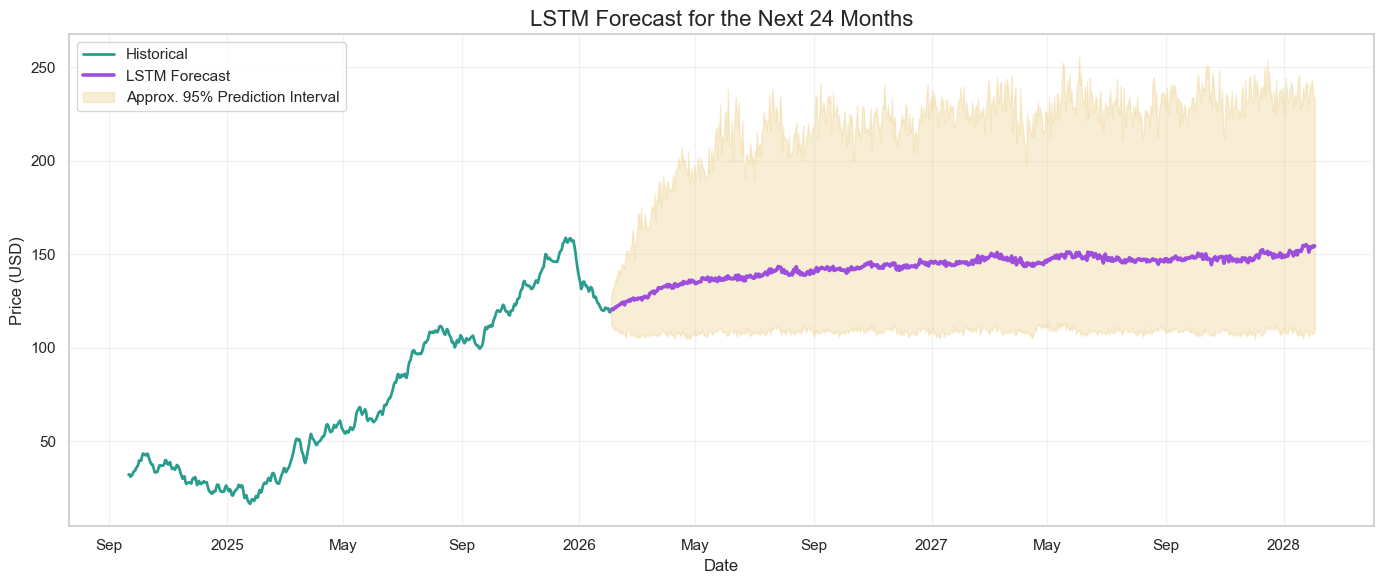

In [109]:
# Plot 27 — Final 24-Month LSTM Forecast with Prediction Intervals
"""
Purpose:
Visualise the final LSTM forecast together with uncertainty bands derived from Monte Carlo dropout.
This is the main forecasting figure for Part 2 and should be included in the report.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    full_series.index,
    full_series.values,
    color=COL["green"],
    linewidth=2.0,
    label="Historical"
)

ax.plot(
    lstm_fc_mean.index,
    lstm_fc_mean.values,
    color=COL["purple"],
    linewidth=2.6,
    label="LSTM Forecast"
)

ax.fill_between(
    lstm_fc_lower.index,
    lstm_fc_lower.values,
    lstm_fc_upper.values,
    color=COL["yellow"],
    alpha=0.28,
    label="Approx. 95% Prediction Interval"
)

ax.set_title("LSTM Forecast for the Next 24 Months")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "27_lstm_24_month_forecast", FIG_DIR)

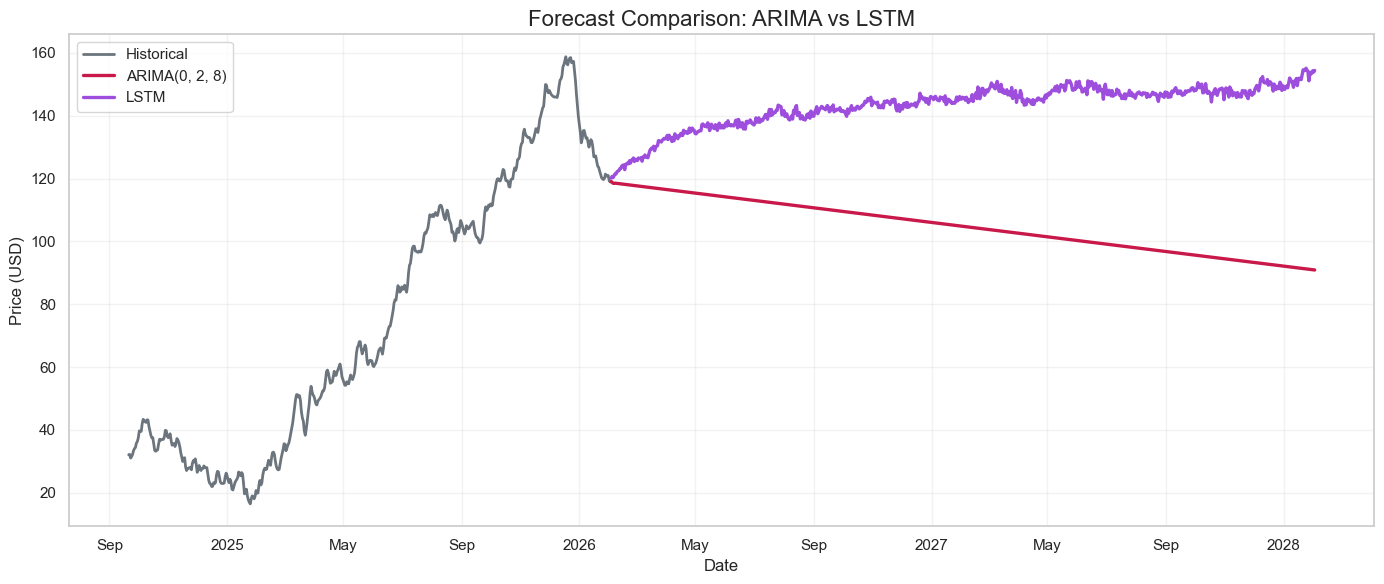

In [110]:
# Plot 28 — Final Forecast Comparison: ARIMA vs LSTM
"""
Purpose:
Compare the long-horizon forecasts produced by ARIMA and LSTM on the same future horizon.
This supports the report's comparative discussion of smoothness, trend behaviour,
and uncertainty differences between models.
"""

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    series.index,
    series.values,
    color=COL["grey"],
    linewidth=2.0,
    label="Historical"
)

ax.plot(
    fc_mean.index,
    fc_mean.values,
    color=COL["rose"],
    linewidth=2.4,
    label=f"ARIMA{SELECTED_ORDER}"
)

ax.plot(
    lstm_fc_mean.index,
    lstm_fc_mean.values,
    color=COL["purple"],
    linewidth=2.4,
    label="LSTM"
)

ax.set_title("Forecast Comparison: ARIMA vs LSTM")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()

prettify_time_axis(ax)
save_and_show(fig, "28_final_forecast_comparison_arima_lstm", FIG_DIR)

In [111]:
# Step 31 — Final Part 2 Summary for Report Writing
"""
Purpose:
Print a concise summary of the alternative model results so the report comparison section is easy to write.
This helps connect the LSTM outputs directly to the assignment requirements on evaluation,
forecasting, and critical comparison.
"""

print("Part 2 summary:")
print(f"LSTM test RMSE: {rmse_lstm:.4f}")
print(f"LSTM test MAE:  {mae_lstm:.4f}")
print(f"LSTM RMSE as % of mean price: {rmse_lstm_pct:.2f}%")
print(f"Approx. 95% LSTM interval coverage on test set: {lstm_coverage_rate:.3%}")
print(f"ARIMA test RMSE: {rmse_arima:.4f}")
print(f"ARIMA test MAE:  {mae_arima:.4f}")
print(f"ARIMA 95% interval coverage on test set: {coverage_rate:.3%}")

if rmse_lstm < rmse_arima:
    print("On RMSE, LSTM outperforms ARIMA on the test set.")
elif rmse_lstm > rmse_arima:
    print("On RMSE, ARIMA outperforms LSTM on the test set.")
else:
    print("On RMSE, ARIMA and LSTM perform similarly on the test set.")

print("\nPoints to discuss in the report:")
print("- LSTM can capture non-linear temporal patterns, unlike ARIMA which is fundamentally linear.")
print("- LSTM requires scaling, sequence construction, and more hyperparameter choices than ARIMA.")
print("- ARIMA is easier to interpret, while LSTM may offer more flexibility at the cost of complexity.")
print("- Recursive multi-step forecasting can accumulate error over long horizons, especially for LSTM.")
print("- Monte Carlo dropout provides approximate uncertainty, but these intervals are less theoretically grounded than ARIMA intervals.")
print("- The final comparison should discuss not only RMSE/MAE, but also interpretability, runtime, stability, and interval behaviour.")

Part 2 summary:
LSTM test RMSE: 29.5574
LSTM test MAE:  27.0366
LSTM RMSE as % of mean price: 38.96%
Approx. 95% LSTM interval coverage on test set: 23.000%
ARIMA test RMSE: 16.5060
ARIMA test MAE:  13.5722
ARIMA 95% interval coverage on test set: 100.000%
On RMSE, ARIMA outperforms LSTM on the test set.

Points to discuss in the report:
- LSTM can capture non-linear temporal patterns, unlike ARIMA which is fundamentally linear.
- LSTM requires scaling, sequence construction, and more hyperparameter choices than ARIMA.
- ARIMA is easier to interpret, while LSTM may offer more flexibility at the cost of complexity.
- Recursive multi-step forecasting can accumulate error over long horizons, especially for LSTM.
- Monte Carlo dropout provides approximate uncertainty, but these intervals are less theoretically grounded than ARIMA intervals.
- The final comparison should discuss not only RMSE/MAE, but also interpretability, runtime, stability, and interval behaviour.
